# Week 2 — Financial Data and Returns

[Open this notebook in Google Colab](https://colab.research.google.com/github/KennethWYLee/FinTech/blob/main/course/02/week2_main.ipynb)

The course repository is public. If the direct Colab link is temporarily unavailable, download `week2_main.ipynb` from GitHub and upload the file to Colab.

This is the complete Week 2 lesson. It integrates preparation, financial concepts, executable examples, output interpretation, discussion questions, evidence checks, independent practice, troubleshooting, extensions, and sources in one document.

## Core financial question

What must be known, checked, and calculated before a table of financial prices can support a valid return calculation?

Week 1 introduced the course workflow. Week 2 establishes the financial-data and return foundation for that workflow. Week 3 will ask when a variable became available, calculate technical indicators and financially motivated features, and convert a stated feature rule into a signal. Week 2 stops before those questions: it does not build a trading signal, fit a prediction model, or report backtest performance.

The sequence stops before technical indicators, trading signals, prediction models, and backtesting. Issues 1–5 first isolate one idea with controlled teaching data and then apply the same idea to a small source-grounded example. Issue 2 makes one fixed historical yfinance request and stores only its result summary, not the downloaded market rows. These examples do not define the common dataset for later strategy work or support an investment recommendation.

Run the notebook from top to bottom. Keep every prediction, output, revision, and unresolved question. A successful execution confirms only that the documented calculations ran in the stated environment; it does not validate a real provider or establish investment value.

## Observable outcome

After completing Week 2, you will produce an audited financial-data record and a reproducible return notebook. The evidence will identify the asset, market, fields, units, currency, timestamps, observation frequency, corporate-action assumptions, data problems, return definitions, frequency conversion, and common holding intervals. It will include simple and log returns, compounded returns, a wealth index, and one-period fixed-weight portfolio returns.

Controlled examples explain the calculation before source-grounded examples apply it to stated observations. The surrounding text and output interpretation identify which evidence is artificial and which comes from a cited source. Neither type of example establishes future investment performance.

## Learning objectives

After completing Week 2, you should be able to:

- identify what a financial-data row and field claim to measure;
- distinguish raw, closing, adjusted, and total-return information without assuming that provider labels are universal;
- calculate and reconcile simple returns, log returns, compounded returns, geometric mean returns, and a wealth index;
- audit asset identity, units, currency, timestamps, duplicates, missing values, invalid values, trading-calendar assumptions, and observation frequency;
- align multiple assets over common holding intervals and calculate a one-period fixed-weight portfolio return; and
- preserve reproducible evidence while limiting conclusions to the data and assumptions actually checked.

## Before you begin

Use a browser-based or local Python notebook with `numpy`, `pandas`, `matplotlib`, and `yfinance`. Issue 2 requires an internet connection to repeat its fixed historical request; the preserved output remains available when students only read the notebook. If the environment is not ready, follow the preparation section below or run the [environment and data check](../resources/notebooks/00_Colab_課前環境與資料檢查.ipynb). A common real dataset, asset universe, and period for later strategy comparison have not yet been approved.

The twenty issues are connected. A field decision changes the return definition; a date or unit error changes the holding interval; and an invalid holding interval makes a portfolio calculation uninterpretable even when the arithmetic is correct.

Issues 1–5 contain two short code examples: a controlled example that isolates the idea and a source-grounded example that applies it. Each code cell has its own checkable prediction and interpretation. Issues 6–20 retain the sequence of question, prediction, executable example, visible output, interpretation, and two discussion questions.

# Navigation through the twenty issues

The twenty issues form five connected sections. The table below shows what each section establishes and why the next section depends on it. All twenty issues remain part of the complete Week 2 material.

| Section | Issues | Main question | Evidence carried forward |
|---|---:|---|---|
| Financial-data meaning and provenance | 1–3 | What does the value represent, where did it come from, and which asset does it describe? | Documented rows, retrieval record, and asset identity |
| Fields, corporate actions, and units | 4–8 | Which field and convention answer the financial question without double counting or unit errors? | Selected price or return field, corporate-action assumptions, and consistent units |
| Return calculation and compounding | 9–14 | How are simple return, log return, compounded return, wealth, and average return calculated and reconciled? | Verified return identities, wealth path, and stated interpretation |
| Data integrity, calendars, and time | 15–18 | Are dates, values, sessions, timestamps, and observation frequencies valid for the intended interval? | Audited rows, unresolved data decisions, and explicit interval boundaries |
| Multi-asset calculation | 19–20 | Do the component returns share one holding interval, and how do fixed starting weights combine them? | Common endpoint table, component returns, weights, contributions, and portfolio return |

The notebook introduces return formulas before the complete data-and-time audit so that each calculation can be examined separately. In an actual analysis, however, apply the dependency in this order:

```text
meaning and source
        ↓
field, event, and unit conventions
        ↓
data and time validation
        ↓
return calculation and compounding
        ↓
same-interval multi-asset calculation
```

A later calculation cannot determine which asset, field meaning, unit, or interval boundary was intended when the source record does not say. Resolve that specific missing information in the relevant earlier section before interpreting the result.

## Working rules

- Use decimal returns in calculations. Convert to percentages only for communication.
- Treat every asset, market, currency, and value labeled artificial as an invented teaching example.
- Do not silently repair a value. Preserve the original, explain the problem, and state the rule used to create any revised version.
- A provider label is not a definition. Real-data work requires the provider documentation and retrieval record.
- Do not include downloaded Yahoo Finance rows or notebook output containing those rows in the course repository unless their permitted use and redistribution have been verified.

# Preparation and required records

## Before class

Use Google Colab or a local Jupyter environment with Python, `numpy`, `pandas`, `matplotlib`, and `yfinance`. Repeating Issue 2 Code 2 also requires an internet connection. If needed, run the [environment and data check](../resources/notebooks/00_Colab_課前環境與資料檢查.ipynb).

Run this notebook from top to bottom. Preserve predictions before each example, visible outputs, revisions, discussion responses, and the requested evidence. Do not include downloaded Yahoo Finance rows or saved notebook output containing those rows in a course submission or repository unless their permitted use and redistribution have been verified.

The preparation notebook uses fixed artificial data and does not download market data. Before class, confirm that you can:

- create and run a notebook from its first cell to its last cell;
- import `numpy`, `pandas`, and `matplotlib`;
- display a `DataFrame` and its `dtypes`;
- save or export the notebook with visible outputs; and
- preserve the complete error message if an environment check fails.

The common market, assets, period, provider fields, currency, and redistribution conditions remain pending. Do not substitute an online dataset into required Week 2 work unless the instructor publishes those decisions.

## Data-processing record

Complete this short record once after finishing the integrated case. It is not a separate form for every issue. Record only facts visible in the source or notebook. Use `pending` when a required fact is not yet known. Do not guess.

```text
Data source and download date:
Asset, market, and currency:
Date range and observation frequency:
Price field used:
Missing or duplicate observations found:
Changes made to the original data:
Return formula and unit:
Unresolved questions:
```

## Data dictionary for the artificial examples

The descriptions below apply only to the artificial examples in this notebook. A real provider's documentation replaces them when real data are approved.

| Field or role | Meaning in the artificial examples | Required check |
|---|---|---|
| `Date` or `Timestamp` | Artificial date or time label under the convention stated in that issue | Parse explicitly; verify uniqueness and order; do not infer a real exchange or time zone |
| `Open` | First artificial price included in the session | Positive and between `Low` and `High` |
| `High` | Largest artificial included price | Positive and not below `Open`, `Close`, or `Low` |
| `Low` | Smallest artificial included price | Positive and not above `Open`, `Close`, or `High` |
| `Close` | Final artificial included price | Positive and between `Low` and `High` |
| `Volume` | Artificial number of traded units included in the session | Nonnegative; unit must be documented before real-data use |
| Issue-specific price series | Artificial price selected for the calculation in that issue | Positive, nonmissing for the required interval, consistently defined, and sorted before returns are calculated |
| `Shares` | Artificial number of shares used in a split or position-value example | Positive and interpreted with the stated event convention |
| `Cash_distribution` | Artificial cash amount included under the stated holding-period convention | Do not add it to a provider-adjusted or total-return field a second time |
| Asset-labelled columns | Artificial price series for different assets | Verify asset identity and align common start and end boundaries before combining returns |

The examples do not use one shared real dataset. The split and cash-distribution calculations in Issues 6–7 and Practice issue 1 are separate artificial cases. Do not apply their event assumptions to another issue unless that issue states them.

## Required audit checks

Preserve the output of every applicable check. A passed assertion does not replace the source record or financial interpretation.

### Identity and metadata

- Each asset has an identifier, name or artificial label, security type, market, and currency entry.
- Provider, dataset, retrieval information, and redistribution status are present.
- Every field has a definition and unit.
- Artificial labels are not presented as real assets or markets.

### Dates and intervals

- Dates parse under an explicit format.
- The index is unique and sorted before returns are calculated.
- Timestamp meaning and time zone are recorded or explicitly pending.
- Calendar gaps are classified using market evidence rather than weekday assumptions alone.
- Multi-asset returns share common start and end boundaries.

### Values and corporate actions

- Prices required by the Week 2 formulas are finite and positive.
- Volume is nonnegative and its unit is known or pending.
- OHLC range relations are checked.
- Missing, repeated, stale, or extreme values remain visible until a documented decision is made.
- Splits, dividends, and adjusted fields are not counted twice.

### Returns and aggregation

- The first return remains missing.
- Simple and log returns reconcile within numerical tolerance.
- Compounded simple return agrees with the endpoint ratio when the assumptions permit that identity.
- The geometric mean reproduces terminal wealth over the same nonmissing periods.
- Frequency conversion uses an aggregation appropriate to each field.
- Portfolio weights are finite, nonnegative, sum to one, and multiply same-interval asset returns.

In [1]:
from importlib.metadata import PackageNotFoundError, version
import platform

import matplotlib as mpl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
    YFINANCE_VERSION = version("yfinance")
except (ImportError, PackageNotFoundError):
    yf = None
    YFINANCE_AVAILABLE = False
    YFINANCE_VERSION = "not installed"

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
plt.rcParams.update(
    {
        "figure.figsize": (7.2, 3.8),
        "figure.dpi": 110,
        "axes.grid": True,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


def show_figure_with_alt_text(figure, alt_text):
    # Display one matplotlib figure with alternative text in notebook output.
    if not isinstance(alt_text, str) or not alt_text.strip():
        raise ValueError("Figure alternative text must be a nonempty string.")
    display(figure, metadata={"image/png": {"alt": alt_text.strip()}})
    plt.close(figure)

environment = pd.Series(
    {
        "Python interface": "Jupyter kernel",
        "Python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": mpl.__version__,
        "yfinance": YFINANCE_VERSION,
        "yfinance_available": YFINANCE_AVAILABLE,
    },
    name="environment",
)
display(environment.rename_axis("Item").to_frame("Value"))

,Value
Item,
Python interface,Jupyter kernel
Python,3.12.9
numpy,2.2.6
pandas,2.2.3
matplotlib,3.10.8
yfinance,1.2.0
yfinance_available,True


## Issue 1 — What does one row of financial data actually say?


A number and a date label do not identify a financial observation. To describe a value as a closing price, the row must identify the asset, venue, field, unit, and meaning of the date or timestamp. These facts explain what the value is intended to represent; they do not prove that the source value is correct.

### Reasoning from the record

Begin with the proposed statement about the value. Break that statement into the asset, venue, field, unit, and time meaning it requires. Accept each part only when the corresponding field is present and defined by the source. Issue 1 does not need an equation because its conclusion depends on documented meaning rather than arithmetic.


### Before Code 1


Predict how many of the five descriptive fields are unstated in `Record A` and in `Record B`. Name the statement that only Record B can support.

In [2]:
row_meaning = pd.DataFrame(
    [
        ["Record A", "Not stated", "Not stated", "Not stated", "Not stated", "Not stated"],
        ["Record B", "Artificial Asset A", "Artificial Exchange", "Closing price", "ACU per share", "End of session"],
    ],
    columns=["Record", "Asset", "Venue", "Field", "Unit", "Timestamp meaning"],
).set_index("Record")
row_meaning["Unstated fields"] = row_meaning.eq("Not stated").sum(axis=1)
display(row_meaning.style.set_caption("Controlled comparison of two artificial records"))
assert row_meaning["Unstated fields"].to_dict() == {"Record A": 5, "Record B": 0}

,Asset,Venue,Field,Unit,Timestamp meaning,Unstated fields
Record,,,,,,
Record A,Not stated,Not stated,Not stated,Not stated,Not stated,5
Record B,Artificial Asset A,Artificial Exchange,Closing price,ACU per share,End of session,0


### Interpret Code 1


Record A leaves all five descriptive fields unstated. Record B leaves none of them unstated and therefore supports describing its value as an end-of-session closing price for the named artificial asset. The example does not identify a real source or prove that either value is correct.


### Real-data example


The [TWSE daily report for security 2330](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330) identifies the security, trading dates, field, and reported values. The [TWSE market-information specification](https://www.twse.com.tw/staticFiles/product/broker/TWSE%E9%9B%86%E4%B8%AD%E5%B8%82%E5%A0%B4%E5%8D%B3%E6%99%82%E4%BA%A4%E6%98%93%E8%B3%87%E8%A8%8A%E5%82%B3%E8%BC%B8%E8%A6%8F%E6%A0%BC%E6%9B%B8%28B.11.17%29%28201903%29-English.pdf) states that the default trading currency is New Taiwan Dollar. Code 2 records two published observations without calculating a return.


### Before Code 2


Predict the security code, field, unit, two trading dates, and two reported values that will appear. Decide whether this information alone proves a total return.

In [3]:
twse_close_rows = pd.DataFrame(
    {
        "Trading date": pd.to_datetime(["2020-02-24", "2020-02-25"]),
        "Security": ["2330 台積電", "2330 台積電"],
        "Field": ["Closing price", "Closing price"],
        "Value": [320.00, 322.00],
        "Unit": ["TWD per share", "TWD per share"],
    }
)
display(twse_close_rows.style.set_caption("TWSE 2330 closing-price observations, 2020-02-24 to 2020-02-25"))
assert twse_close_rows["Value"].tolist() == [320.00, 322.00]

,Trading date,Security,Field,Value,Unit
0,2020-02-24 00:00:00,2330 台積電,Closing price,320.000000,TWD per share
1,2020-02-25 00:00:00,2330 台積電,Closing price,322.000000,TWD per share


### Interpret Code 2


The table identifies two TWSE 2330 closing-price observations: TWD 320.00 per share on 2020-02-24 and TWD 322.00 per share on 2020-02-25. It does not contain cash distributions or an adjusted-price definition, so it does not by itself establish a total return. Issue 1 stops after identifying what each row says.


### Discussion questions

1. A file contains `2026-01-05, 100` and `2026-01-06, 105`. An analyst reports a 5% one-period return. Identify the facts that must be confirmed before accepting this conclusion. For at least three facts, give a concrete alternative that would make the 5% conclusion incorrect.
2. Two files contain only `Date` and `Value`. Their filenames identify different assets and currencies. After the files are combined, the filenames are lost. Decide which columns must be added before combining the files. Explain one specific error this omission could cause when calculating a portfolio return.

## Issue 2 — What must be recorded when financial data are requested?


A data request has two different parts: the settings sent to the access library and the rows returned by the provider. The settings must state the symbol, date boundaries, interval, and options that change the fields. The result must state whether rows were returned and which dates and columns appeared.

The [yfinance project notice](https://github.com/ranaroussi/yfinance/blob/main/README.md) explains that the library accesses Yahoo Finance data and is not affiliated with, endorsed by, or vetted by Yahoo. The [download documentation](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html) defines the arguments used below. Code 2 makes one fixed historical request but displays only a result summary, not downloaded market rows.

### Reasoning and boundary condition

Let $d$ be the date attached to a returned daily row, $s$ the inclusive start boundary, and $e$ the exclusive end boundary. A row belongs inside the requested date range only when:

$$
d \in [s,e)
\quad\Longleftrightarrow\quad
s \leq d < e.
$$

For this request:

$$
s=\text{2024-01-02},
\qquad
e=\text{2024-01-10}.
$$

The left boundary is included and the right boundary is excluded. This condition limits eligible dates; it does not guarantee that every eligible calendar date is a trading date or that the provider will return a row.


### Before Code 1


Predict the symbol, inclusive start date, exclusive end date, interval, and adjustment setting that the query table will show. Explain why changing one of these values creates a different request.

In [4]:
yf_query = pd.Series(
    {
        "symbol": "MSFT",
        "start (inclusive)": "2024-01-02",
        "end (exclusive)": "2024-01-10",
        "interval": "1d",
        "auto_adjust": False,
    },
    name="Recorded value",
)
display(yf_query.to_frame().style.set_caption("Fixed yfinance request settings"))
assert yf_query["auto_adjust"] is False

,Recorded value
symbol,MSFT
start (inclusive),2024-01-02
end (exclusive),2024-01-10
interval,1d
auto_adjust,False


### Interpret Code 1


The table specifies MSFT daily observations beginning on 2024-01-02 and ending before 2024-01-10, with automatic price adjustment disabled. It describes the intended request but contains no evidence that a request succeeded or that any rows exist.


### Real-data example


Code 2 sends the recorded request through yfinance. The output reports the number of returned rows, first and last dates, and column names. The exact result depends on the provider response and the installed package version; the saved notebook output records the result observed during verification.


### Before Code 2


Predict whether the fixed period will return at least one row. Name the first and last trading dates you expect inside the inclusive-start and exclusive-end boundaries, and predict whether the result will contain both Close and Adj Close.

In [5]:
if not YFINANCE_AVAILABLE:
    raise ModuleNotFoundError("Install yfinance before running Issue 2 Code 2.")

yf_rows = yf.download(
    "MSFT", start="2024-01-02", end="2024-01-10", interval="1d",
    auto_adjust=False, progress=False, threads=False, multi_level_index=False,
)
yf_result = pd.Series(
    {
        "rows returned": len(yf_rows),
        "first date": str(yf_rows.index.min().date()),
        "last date": str(yf_rows.index.max().date()),
        "columns": ", ".join(map(str, yf_rows.columns)),
    },
    name="Observed result",
)
display(yf_result.to_frame().style.set_caption("Observed result of the fixed MSFT request"))
observed_signature = (len(yf_rows), str(yf_rows.index.min().date()), str(yf_rows.index.max().date()))
assert observed_signature == (6, "2024-01-02", "2024-01-09") and {"Close", "Adj Close"}.issubset(yf_rows.columns)

,Observed result
rows returned,6
first date,2024-01-02
last date,2024-01-09
columns,"Adj Close, Close, High, Low, Open, Volume"


### Interpret Code 2


The verified request returned six daily rows. The first date is 2024-01-02 and the last date is 2024-01-09, which is consistent with the inclusive start and exclusive end settings. The returned columns include Close and Adj Close. These observations show what this request returned during verification; they do not prove that another package version, later provider response, or changed query will return identical rows.


### Discussion questions

1. Team A requests MSFT with auto_adjust=True; Team B uses the same dates with auto_adjust=False. Identify the exact returned columns and calculations that must be compared before the teams attribute a return difference to their models. State whether the two return series can be treated as the same input before this check is complete.
2. A later run returns seven rows rather than the six preserved here. First test whether every returned date satisfies $2024\text{-}01\text{-}02 \leq d < 2024\text{-}01\text{-}10$. Then compare the first date, last date, column names, package version, and query settings. State which differences show a changed request and which show a changed provider result under the same request.

## Issue 3 — How do we identify the asset behind a ticker symbol?


A ticker symbol is used within a particular source, trading venue, and period. Different venues can use the same symbol, and one security can change its symbol. A price row should therefore retain the provider asset identifier, security name and class, venue, ticker, and effective dates needed for that source.

### Reasoning from the records

A symbol match identifies possible rows, not necessarily one security. First count the matches under the provider and effective period. If more than one row remains, the price cannot be assigned until an identifier or documented mapping selects one row. Issue 3 does not need a financial equation because the conclusion follows from identity evidence and effective dates.


### Before Code 1


Predict how many rows the one-row price table will produce when it is joined to the two-row asset table by Symbol alone. Name the field that would allow one intended asset to be selected before the join.

In [6]:
asset_lookup = pd.DataFrame(
    [
        ["P003", "XYZ", "Artificial X Fund", "Fund", "Venue X"],
        ["P004", "XYZ", "Artificial X Share", "Common stock", "Venue Y"],
    ],
    columns=["Provider asset ID", "Symbol", "Asset", "Security type", "Venue"],
)
price_row = pd.DataFrame({"Symbol": ["XYZ"], "Close": [100.0]})
symbol_only_result = price_row.merge(asset_lookup, on="Symbol", how="left")
display(symbol_only_result.style.set_caption("Artificial symbol-only join with two possible asset matches"))
assert len(symbol_only_result) == 2

,Symbol,Close,Provider asset ID,Asset,Security type,Venue
0,XYZ,100.000000,P003,Artificial X Fund,Fund,Venue X
1,XYZ,100.000000,P004,Artificial X Share,Common stock,Venue Y


### Interpret Code 1


The one price row becomes two rows because both artificial assets use XYZ. Selecting the first match would attach the price without evidence. The provider asset identifier must be present in the price record or recovered from a documented mapping before the join can identify one asset.


### Real-data example


The [Meta Platforms Form 8-K](https://www.sec.gov/Archives/edgar/data/1326801/000132680122000070/fb-20220531.htm) states that its Class A common stock would begin trading on the Nasdaq Global Select Market under META before market open on 2022-06-09. The attached [company announcement](https://www.sec.gov/Archives/edgar/data/1326801/000132680122000070/may312022-exhibit991.htm) states that META replaced FB and that the CUSIP number remained unchanged. Code 2 records the two ticker periods supported by those documents.


### Before Code 2


Predict whether the table will describe one security or two securities. Predict the last date assigned to FB and the first date assigned to META.

In [7]:
meta_ticker_periods = pd.DataFrame(
    [
        ["Meta Platforms, Inc.", "Class A common stock", "FB", "Through 2022-06-08"],
        ["Meta Platforms, Inc.", "Class A common stock", "META", "From 2022-06-09"],
    ],
    columns=["Issuer", "Security class", "Ticker", "Effective period"],
)
meta_ticker_periods["CUSIP continuity"] = "Unchanged in cited announcement"
display(meta_ticker_periods.style.set_caption("Meta Class A common-stock ticker periods stated by the cited SEC filing"))
assert meta_ticker_periods["Security class"].nunique() == 1

,Issuer,Security class,Ticker,Effective period,CUSIP continuity
0,"Meta Platforms, Inc.",Class A common stock,FB,Through 2022-06-08,Unchanged in cited announcement
1,"Meta Platforms, Inc.",Class A common stock,META,From 2022-06-09,Unchanged in cited announcement


### Interpret Code 2


The table contains one issuer and one security class across two ticker periods: FB through 2022-06-08 and META from 2022-06-09. The stated CUSIP continuity supports linking the periods as one security history. The cited documents do not state the trading currency, so the code does not add one.


### Discussion questions

1. A price table contains one XYZ row and no provider asset identifier. Joining by Symbol produces the two matches shown in Code 1. Specify the exact additional value needed to select P003 rather than P004, and state why venue or security type should not be guessed from the price value.
2. A historical file contains FB rows through 2022-06-08 and META rows from 2022-06-09, but its asset table stores only META. Specify the identifier and effective-date fields needed to retain both periods. Explain the false conclusion produced by treating the two ticker labels as two unrelated investments.

## Issue 4 — What exactly do Open, High, Low, Close, and Volume summarize?


For one stated interval, Open is the first included price, High is the largest included price, Low is the smallest included price, Close is the final included price, and Volume is the provider's reported traded quantity. The field names alone do not identify the included trading hours or the unit counted by Volume.

### Symbols and units

Let $p_{t,j}$ be the $j$th included price in interval $t$, $q_{t,j}$ its included quantity, and $n_t$ the number of included trades. Every price must describe the same asset, currency, price unit, and interval. Every quantity must use the same stated volume unit.

### Reasoning and formulation

$$
\begin{aligned}
O_t &= p_{t,1},\\
H_t &= \max_{1\leq j\leq n_t} p_{t,j},\\
L_t &= \min_{1\leq j\leq n_t} p_{t,j},\\
C_t &= p_{t,n_t},\\
V_t &= \sum_{j=1}^{n_t} q_{t,j}.
\end{aligned}
$$

The price order determines Open and Close; the price values determine High and Low; the quantities determine Volume. If rows from different assets or intervals are mixed, these equations still produce numbers but those numbers do not describe one valid OHLCV interval.


### Before Code 1


The four artificial trades have prices 100, 103, 99, and 102, with quantities 100, 200, 150, and 50. Predict all five OHLCV values before running the calculation.

In [8]:
trades = pd.DataFrame(
    {
        "Time": ["09:00", "09:05", "09:10", "13:25"],
        "Price": [100.0, 103.0, 99.0, 102.0],
        "Quantity": [100, 200, 150, 50],
    }
)
artificial_ohlcv = pd.DataFrame(
    {"Open": [trades["Price"].iloc[0]], "High": [trades["Price"].max()],
     "Low": [trades["Price"].min()], "Close": [trades["Price"].iloc[-1]],
     "Volume": [trades["Quantity"].sum()]},
    index=["Artificial session"],
)
display(artificial_ohlcv.style.set_caption("OHLCV calculated from four artificial trades; prices in ACU and volume in quantity units"))
assert artificial_ohlcv.iloc[0].tolist() == [100.0, 103.0, 99.0, 102.0, 500.0]

,Open,High,Low,Close,Volume
Artificial session,100.000000,103.000000,99.000000,102.000000,500


### Interpret Code 1


The artificial session produces Open 100, High 103, Low 99, Close 102, and Volume 500 units:

$$
(O_t,H_t,L_t,C_t,V_t)=(100,103,99,102,500).
$$

Those values follow directly from the four displayed trades. They do not describe a real exchange or establish which real transaction categories a provider includes.


### Real-data example


The [TWSE daily report for security 2330](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330) reports the daily fields for 2020-02-24 and states which transaction categories its daily statistics include and exclude. Code 2 checks the numerical price relationships while retaining the source's traded-share unit.


### Before Code 2


Predict the five reported values and whether Low is at or below both Open and Close and High is at or above both. State what those checks cannot reveal about the transactions included in Volume.

In [9]:
twse_ohlcv = pd.DataFrame(
    {
        "Open": [319.50], "High": [321.50], "Low": [319.50],
        "Close": [320.00], "Traded shares": [42_946_680],
    },
    index=[pd.Timestamp("2020-02-24")],
)
twse_ohlcv["Price relationships pass"] = (
    (twse_ohlcv["Low"] <= twse_ohlcv[["Open", "Close"]].min(axis=1))
    & (twse_ohlcv["High"] >= twse_ohlcv[["Open", "Close"]].max(axis=1))
)
display(twse_ohlcv.style.set_caption("TWSE 2330 daily fields for 2020-02-24; prices in TWD per share"))
assert twse_ohlcv["Price relationships pass"].all()

,Open,High,Low,Close,Traded shares,Price relationships pass
2020-02-24 00:00:00,319.500000,321.500000,319.500000,320.000000,42946680,True


### Interpret Code 2


The TWSE row reports Open 319.50, High 321.50, Low 319.50, Close 320.00, and 42,946,680 traded shares. Its price relationships pass. That numerical result cannot establish which trading categories are included; the volume description must retain the scope stated in the official report.


### Discussion questions

1. A provider reports Open 102.0, High 101.0, Low 100.5, and Close 102.5 for one interval. Substitute the values into the two High relationships, identify both failures, and state which original records must be checked before changing any field.
2. The real TWSE row passes its price relationships and reports 42,946,680 traded shares. Rewrite the Volume description so it retains the transaction scope stated by the source, and explain why the Boolean price checks cannot verify that scope.

## Issue 5 — Which price field matches the return being measured?


A quoted closing price, a provider-adjusted closing price, and a total-return index can describe different changes. Select the field from the financial question and the provider's definition, not from whichever column produces the largest historical return.

### Symbols and units

Let $F_{t-1}$ and $F_t$ be values from the same field construction, asset, currency, and unit at the beginning and end of one stated interval. Let $r_t^{(F)}$ be that field's decimal return. The beginning value must be nonzero; a price input used here must also be positive.

### Reasoning and derivation

First define the change in the field:

$$
\Delta F_t = F_t-F_{t-1}.
$$

Divide that change by the beginning field value and substitute the definition of $\Delta F_t$:

$$
\begin{aligned}
r_t^{(F)}
&=\frac{\Delta F_t}{F_{t-1}}\\
&=\frac{F_t-F_{t-1}}{F_{t-1}}\\
&=\frac{F_t}{F_{t-1}}-1,
\qquad F_{t-1}\neq 0.
\end{aligned}
$$

The algebra is the same for each column, but the financial meaning comes from the field definition. Applying this calculation to a raw close produces a quoted closing-price return. Applying it to an adjusted field or total-return index inherits that provider's documented transformations.


### Before Code 1


Predict the return for each artificial field. Identify which result describes quoted price change, which applies an unspecified provider adjustment, and which includes the stated artificial distribution treatment.

In [10]:
field_comparison = pd.DataFrame(
    {
        "Field": ["Raw close", "Provider-adjusted close", "Artificial total-return index"],
        "Beginning value": [100.0, 50.0, 100.0],
        "Ending value": [50.0, 50.0, 100.5],
    }
)
field_comparison["Return"] = (
    field_comparison["Ending value"] / field_comparison["Beginning value"] - 1
)
display(field_comparison.style.set_caption("Artificial one-period returns calculated from three differently constructed fields"))
assert np.allclose(field_comparison["Return"], [-0.50, 0.0, 0.005])

,Field,Beginning value,Ending value,Return
0,Raw close,100.000000,50.000000,-0.500000
1,Provider-adjusted close,50.000000,50.000000,0.000000
2,Artificial total-return index,100.000000,100.500000,0.005000


### Interpret Code 1


The raw close falls by 50%, the provider-adjusted close is unchanged, and the artificial total-return index rises by 0.5%. The calculations differ because the input fields have different stated constructions. This artificial example does not reproduce any real provider's adjustment method.


### Real-data example


The [TWSE daily report for security 2330](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330) displays closing prices of 320.00 and 322.00 for 2020-02-24 and 2020-02-25. It does not display an adjusted close, cash distribution, or total-return index. Code 2 therefore calculates only a closing-price return.


### Before Code 2


Predict the closing-price return from 320.00 to 322.00. Decide whether the available fields allow the result to be described as adjusted or distribution-inclusive.

In [11]:
twse_closes = pd.DataFrame(
    {"Close": [320.00, 322.00]},
    index=pd.to_datetime(["2020-02-24", "2020-02-25"]),
)
twse_closes["Closing-price return"] = twse_closes["Close"].pct_change(fill_method=None)
display(twse_closes.style.set_caption("TWSE 2330 closing prices and closing-price return, 2020-02-24 to 2020-02-25"))
assert np.isclose(twse_closes["Closing-price return"].iloc[1], 0.00625)

,Close,Closing-price return
2020-02-24 00:00:00,320.000000,nan
2020-02-25 00:00:00,322.000000,0.006250


### Interpret Code 2


The closing-price return ending on 2020-02-25 is obtained by substituting the two reported closing prices:

$$
\begin{aligned}
r_{\text{2020-02-25}}^{(\mathrm{Close})}
&=\frac{322-320}{320}\\
&=0.00625\\
&=0.625\%.
\end{aligned}
$$

The official table supports the two closing-price endpoints. Because this source table does not supply an adjusted-close definition, cash distribution, or total-return index, this result cannot be relabeled as an adjusted or distribution-inclusive return.


### Discussion questions

1. Starting from $\Delta F_t/F_{t-1}$, derive the TWSE result as $(322-320)/320$, then show that it equals $322/320-1=0.00625$. List the provider definition and corporate-action information still required before reporting an adjusted or distribution-inclusive return.
2. An adjusted series changes from 100 to 101 and its provider states that the change already includes a cash distribution of 2. Calculate the return from the adjusted series and the result from adding 2 again. Identify the duplicated amount and state which provider definition would resolve the calculation.

## Issue 6 — How can a stock split change price and share count without changing position value?


A stock split changes the number of shares represented by each pre-split share. In a two-for-one split, one old share becomes two new shares. If nothing else changes, the price per share halves while the number of shares doubles.

The raw price-per-share return then reports a 50% decline even though the total value of the position is unchanged. A real market price can also move around the split date, so the split ratio, effective date, and price observations must be checked separately.

This artificial example assumes an exact two-for-one split, no other price movement, no fees, and no tax effect. It explains the arithmetic only. It does not show how a real provider adjusts historical prices.

The real event record uses Apple's [July 30, 2020 announcement](https://www.apple.com/newsroom/2020/07/apple-reports-third-quarter-results/) and [investor-relations history](https://investor.apple.com/dividend-history/default.aspx). Apple stated that each shareholder of record at the close of business on August 24 would receive three additional shares for every share held, and that split-adjusted trading would begin on August 31. The code applies the announced four-for-one ratio to a notional one-share holding. It does not insert market prices or claim that Apple's position value was unchanged by market movement.


### Before running the example


Predict the percentage change in price per share, number of shares, and total position value in the artificial two-for-one example. Then use the announced Apple ratio to predict the notional quantity and mechanical per-share scale after a four-for-one split. Keep the prediction separate from any actual market-price movement.

,Price_per_share,Shares,Position_value
Before split,100.000000,1.000000,100.000000
After split,50.000000,2.000000,100.000000


,Return_decimal,Return_percent
Raw per-share price,-0.500000,-50.000000
Position value,0.000000,0.000000


Raw per-share return: -0.5
Position value before: 100.0
Position value after: 100.0
Position-value return: 0.0


Issuer,Split_ratio_new_per_old,Additional_shares_per_old_share,Record_date,Split_adjusted_trading_date,Source_statement
Apple Inc.,4.000000,3.000000,2020-08-24 00:00:00,2020-08-31 00:00:00,Four-for-one split; three additional shares for each share held


,Quantity,Mechanical_price_scale,Quantity_times_price_scale
Before announced split,1.000000,1.000000,1.000000
After applying announced ratio,4.000000,0.250000,1.000000


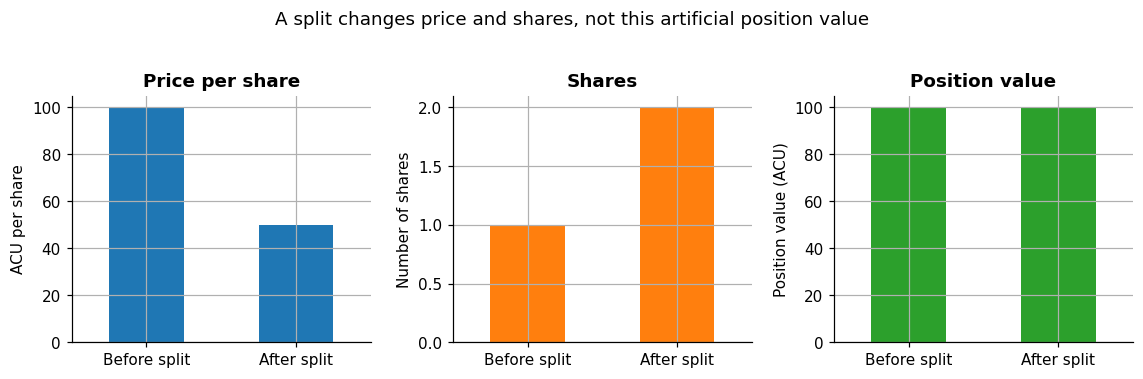

In [12]:
split_example = pd.Series(
    {
        "price_before": 100.0,
        "shares_before": 1.0,
        "split_ratio_new_per_old": 2.0,
        "price_after": 50.0,
        "shares_after": 2.0,
    }
)

raw_per_share_return = split_example["price_after"] / split_example["price_before"] - 1
value_before = split_example["price_before"] * split_example["shares_before"]
value_after = split_example["price_after"] * split_example["shares_after"]
position_value_return = value_after / value_before - 1

split_table = pd.DataFrame(
    {
        "Price_per_share": [split_example["price_before"], split_example["price_after"]],
        "Shares": [split_example["shares_before"], split_example["shares_after"]],
        "Position_value": [value_before, value_after],
    },
    index=["Before split", "After split"],
)
split_return_table = pd.DataFrame(
    {
        "Return_decimal": [raw_per_share_return, position_value_return],
        "Return_percent": [100 * raw_per_share_return, 100 * position_value_return],
    },
    index=["Raw per-share price", "Position value"],
)

display(
    split_table.style.set_caption(
        "Artificial two-for-one split: price, shares, and position value"
    )
)
display(
    split_return_table.round(4).style.set_caption(
        "Returns calculated from price per share and total position value"
    )
)
print("Raw per-share return:", raw_per_share_return)
print("Position value before:", value_before)
print("Position value after:", value_after)
print("Position-value return:", position_value_return)

apple_split_record = pd.DataFrame(
    {
        "Issuer": ["Apple Inc."],
        "Split_ratio_new_per_old": [4.0],
        "Additional_shares_per_old_share": [3.0],
        "Record_date": [pd.Timestamp("2020-08-24")],
        "Split_adjusted_trading_date": [pd.Timestamp("2020-08-31")],
        "Source_statement": [
            "Four-for-one split; three additional shares for each share held"
        ],
    }
)

apple_notional_split = pd.DataFrame(
    {
        "Quantity": [1.0, 4.0],
        "Mechanical_price_scale": [1.0, 0.25],
        "Quantity_times_price_scale": [1.0, 1.0],
    },
    index=["Before announced split", "After applying announced ratio"],
)

display(
    apple_split_record.style.set_caption(
        "Real Apple split terms stated in the official announcement"
    ).hide(axis="index")
)
display(
    apple_notional_split.style.set_caption(
        "Mechanical effect of Apple's announced four-for-one ratio on a notional holding"
    )
)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.3))
for axis, column, color in zip(
    axes,
    ["Price_per_share", "Shares", "Position_value"],
    ["tab:blue", "tab:orange", "tab:green"],
):
    split_table[column].plot(kind="bar", ax=axis, color=color, rot=0)
    axis.set_title(column.replace("_", " "))
    axis.set_xlabel("")
axes[0].set_ylabel("ACU per share")
axes[1].set_ylabel("Number of shares")
axes[2].set_ylabel("Position value (ACU)")
fig.suptitle("A split changes price and shares, not this artificial position value", y=1.03)
plt.tight_layout()
show_figure_with_alt_text(
    fig,
    "Three bar panels for an artificial two-for-one split. Price per share halves, "
    "share quantity doubles, and position value remains 100 ACU.",
)

assert np.isclose(raw_per_share_return, -0.50)
assert np.isclose(position_value_return, 0.0)
assert np.isclose(apple_split_record.loc[0, "Split_ratio_new_per_old"], 4.0)
assert np.isclose(apple_notional_split.loc["After applying announced ratio", "Quantity"], 4.0)
assert np.isclose(
    apple_notional_split.loc[
        "After applying announced ratio", "Quantity_times_price_scale"
    ],
    1.0,
)

### Interpret the output


The price per share falls from 100 to 50, so the raw per-share return is negative 50%. The number of shares rises from one to two. Multiplying price by shares gives a position value of 100 before and after the event, so the position-value return is zero.

The three panels show these three quantities separately. Their titles and positions identify the quantity even without color.

An observed price halving does not prove that a split occurred. Confirm the provider asset identifier, split ratio, effective date, price field, and adjustment rule before changing a real return series.

The Apple table records a four-for-one ratio, so the notional share quantity increases from one to four and the purely mechanical per-share scale becomes one quarter. Their product remains one. This is a ratio check, not a realized return calculation. Actual prices before and after the event may also reflect market movement, and a provider may already store split-adjusted history.


### Discussion questions

1. A provider records a two-for-one split. One share priced at 100 becomes two shares priced at 52. Calculate the raw price-per-share return and the position-value return. Separate the mechanical effect of the split from the remaining change in position value, and list the provider fields needed to confirm that both prices and the share count refer to the same event boundary.
2. Apple's official record states a four-for-one split and split-adjusted trading beginning on 2020-08-31. A downloaded price series is documented as already split-adjusted, but a student divides all pre-split observations by four again. Explain how the second adjustment changes the apparent return across the event. Specify the source field definition, event record, date boundary, and code line that must be checked before deciding whether any adjustment is still required.

## Issue 7 — How does a cash distribution change a holding-period return?


A price return uses only the beginning and ending prices. A holding-period return can also include cash that the investor became entitled to receive during the interval.

Before adding a cash distribution, confirm that the investor held the asset under the applicable eligibility rule. Also confirm the amount per share, currency, relevant dates, tax treatment, and whether the selected price field already includes the distribution.

The artificial example assumes one share, a cash distribution of 3 ACU, no reinvestment, no tax, and no currency conversion. It separates the price-only change from the change in ending value plus cash. It does not reproduce a real provider's total-return series.

The real event record uses Microsoft's [June 12, 2024 dividend announcement](https://news.microsoft.com/source/2024/06/12/microsoft-announces-quarterly-dividend-23/) and its [investor-relations dividend history](https://www.microsoft.com/en-us/Investor/dividends-and-stock-history). Microsoft announced a quarterly dividend of USD 0.75 per share, an ex-dividend and record date of August 15, 2024, and a payable date of September 12, 2024. The code calculates cash amounts only for a stated number of eligible shares. It does not insert a market price, model tax, or construct a total return.


### Before running the example


Calculate the artificial price-only return and the return after adding the 3 ACU cash distribution. Predict which result is negative and which result is positive. Then calculate the gross cash implied by Microsoft's announced USD 0.75 amount for 100 eligible shares without assuming that any particular investor was eligible.

,Amount
Beginning price,100.000000
Ending price,98.000000
Cash distribution,3.000000
Ending value plus cash,101.000000


,Return_decimal,Return_percent
Price return,-0.020000,-2.000000
Simplified holding-period return,0.010000,1.000000


Price return: -0.020000000000000018
Simplified holding-period return: 0.010000000000000009


Issuer,Ticker,Cash_per_share_USD,Announcement_date,Ex_dividend_date,Record_date,Payable_date
Microsoft Corporation,MSFT,0.750000,2024-06-12 00:00:00,2024-08-15 00:00:00,2024-08-15 00:00:00,2024-09-12 00:00:00


,Eligible_shares,Cash_per_share_USD,Gross_cash_USD
One eligible share,1,0.750000,0.750000
One hundred eligible shares,100,0.750000,75.000000


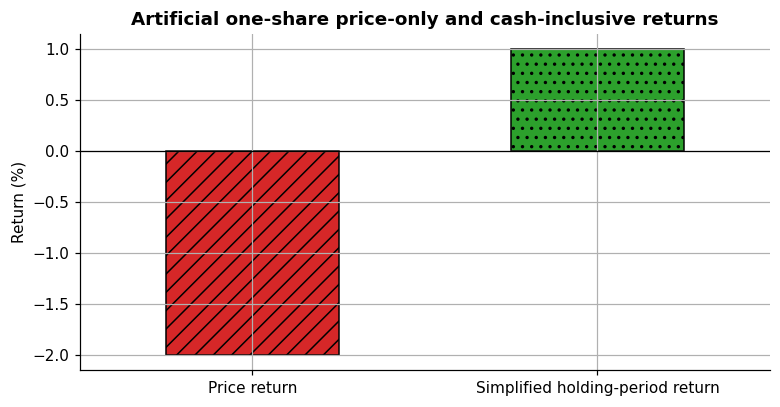

In [13]:
dividend_example = pd.Series(
    {
        "price_before": 100.0,
        "price_after": 98.0,
        "cash_distribution": 3.0,
    }
)

price_return = dividend_example["price_after"] / dividend_example["price_before"] - 1
holding_period_return = (
    dividend_example["price_after"] + dividend_example["cash_distribution"]
) / dividend_example["price_before"] - 1

dividend_value_table = pd.DataFrame(
    {
        "Amount": [
            dividend_example["price_before"],
            dividend_example["price_after"],
            dividend_example["cash_distribution"],
            dividend_example["price_after"] + dividend_example["cash_distribution"],
        ]
    },
    index=["Beginning price", "Ending price", "Cash distribution", "Ending value plus cash"],
)
dividend_return_table = pd.DataFrame(
    {
        "Return_decimal": [price_return, holding_period_return],
        "Return_percent": [100 * price_return, 100 * holding_period_return],
    },
    index=["Price return", "Simplified holding-period return"],
)

display(
    dividend_value_table.style.set_caption(
        "Artificial price and cash amounts for one share over one interval"
    )
)
display(
    dividend_return_table.round(4).style.set_caption(
        "Price-only and cash-inclusive returns for the artificial interval"
    )
)
print("Price return:", price_return)
print("Simplified holding-period return:", holding_period_return)

microsoft_dividend_record = pd.DataFrame(
    {
        "Issuer": ["Microsoft Corporation"],
        "Ticker": ["MSFT"],
        "Cash_per_share_USD": [0.75],
        "Announcement_date": [pd.Timestamp("2024-06-12")],
        "Ex_dividend_date": [pd.Timestamp("2024-08-15")],
        "Record_date": [pd.Timestamp("2024-08-15")],
        "Payable_date": [pd.Timestamp("2024-09-12")],
    }
)

microsoft_cash_examples = pd.DataFrame(
    {
        "Eligible_shares": [1, 100],
        "Cash_per_share_USD": [0.75, 0.75],
    },
    index=["One eligible share", "One hundred eligible shares"],
)
microsoft_cash_examples["Gross_cash_USD"] = (
    microsoft_cash_examples["Eligible_shares"]
    * microsoft_cash_examples["Cash_per_share_USD"]
)

display(
    microsoft_dividend_record.style.set_caption(
        "Real Microsoft dividend terms stated in the official announcement"
    ).hide(axis="index")
)
display(
    microsoft_cash_examples.style.set_caption(
        "Cash implied by the announced amount for stated eligible share counts"
    )
)

ax = dividend_return_table["Return_percent"].plot(
    kind="bar",
    color=["tab:red", "tab:green"],
    edgecolor="black",
    rot=0,
)
ax.patches[0].set_hatch("//")
ax.patches[1].set_hatch("..")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Return (%)")
ax.set_title("Artificial one-share price-only and cash-inclusive returns")
plt.tight_layout()
show_figure_with_alt_text(
    ax.figure,
    "Two artificial return bars: price-only return is negative 2 percent, while the "
    "cash-inclusive return is positive 1 percent.",
)

assert np.isclose(price_return, -0.02)
assert np.isclose(holding_period_return, 0.01)
assert np.isclose(
    microsoft_cash_examples.loc["One hundred eligible shares", "Gross_cash_USD"],
    75.0,
)

### Interpret the output


The price falls from 100 to 98, so the price return is negative 2%. Adding the assumed 3 ACU cash distribution gives an ending value of 101 and a cash-inclusive return of positive 1%.

The return table labels the two calculations separately. The bar labels and hatch patterns keep them distinguishable without relying only on color.

Do not call the second result a provider total return. The example does not model reinvestment timing, taxes, currency conversion, eligibility rules, or the provider's adjusted-price method.

The Microsoft event table separates the ex-dividend, record, and payable dates instead of treating them as one date. At USD 0.75 per eligible share, 100 eligible shares imply USD 75 of gross cash. This multiplication does not establish that a particular investor was eligible and does not show the investor's after-tax or currency-converted return.


### Discussion questions

1. An investor buys the asset after its ex-dividend date but before its payment date. The price falls from 100 to 98, and a payment of 3 is made during the investor's holding period. Identify the event dates and ownership information needed before adding the payment to this investor's return. State how the reported return changes if the investor was not entitled to the payment.
2. Microsoft announced USD 0.75 per share with an ex-dividend date of 2024-08-15 and a payable date of 2024-09-12. A student buys 100 shares on 2024-08-16, observes the later cash-payment date, and adds USD 75 to the holding return. Decide whether the announcement alone supports that addition. Identify the acquisition, ownership, settlement, price-field, tax, and currency evidence needed before the student's personal return can include the payment.

## Issue 8 — Do the numbers, units, currencies, and percentage labels agree?


A calculation can use the correct formula and still report the wrong result if its units are mislabeled. A decimal return of 0.01, a percentage return of 1%, and 100 basis points describe the same proportional change.

A change from 4% to 5% equals one percentage point. Relative to the starting rate of 4%, the increase is 25%. These are different calculations with different denominators.

Currency labels require the same care. Returns measured in different local currencies do not automatically describe the change in wealth of one investor. If the investor measures wealth in ACU, an asset priced in BCU also requires the BCU-to-ACU exchange-rate change over the same interval.

The real rate example uses the Federal Reserve's [July 26, 2023 FOMC statement](https://www.federalreserve.gov/newsevents/pressreleases/monetary20230726a.htm) and its [record of policy actions](https://www.federalreserve.gov/publications/2023-ar-record-of-policy-actions-of-the-board-of-governors.htm). The record describes a 25-basis-point increase to a target range of 5.25% to 5.50%. The code separates that 0.25-percentage-point change from the relative percentage change in each boundary.


### Before running the example


Predict the common decimal value of 1%, 100 basis points, and 0.01. Then predict both the percentage-point change and relative change when a rate moves from 4% to 5%. For the real target range, predict whether the two boundaries have the same basis-point change and the same relative percentage change.

In [14]:
unit_examples = pd.DataFrame(
    {
        "Input_label": ["decimal return", "percentage return", "basis points", "rate change"],
        "Input_value": [0.01, 1.0, 100.0, 5.0 - 4.0],
        "Converted_decimal": [0.01, 1.0 / 100, 100.0 / 10_000, np.nan],
        "Communication": ["1%", "1%", "1%", "1 percentage point"],
    }
)

display(
    unit_examples.style.set_caption(
        "Equivalent return units and a separate percentage-point example"
    ).hide(axis="index")
)

fomc_range_change = pd.DataFrame(
    {
        "Boundary": ["Lower bound", "Upper bound"],
        "Before_percent": [5.00, 5.25],
        "After_percent": [5.25, 5.50],
    }
)
fomc_range_change["Change_percentage_points"] = (
    fomc_range_change["After_percent"] - fomc_range_change["Before_percent"]
)
fomc_range_change["Change_basis_points"] = (
    100 * fomc_range_change["Change_percentage_points"]
)
fomc_range_change["Relative_change_percent"] = 100 * (
    fomc_range_change["After_percent"] / fomc_range_change["Before_percent"] - 1
)

display(
    fomc_range_change.round(4).style.set_caption(
        "Real July 2023 federal funds target-range change in three units"
    ).hide(axis="index")
)
print("100 basis points in decimal units:", 100 / 10_000)
print("Rate change from 4% to 5%:", 5 - 4, "percentage point")
print("Relative increase from 4% to 5%:", 5.0 / 4.0 - 1.0)

assert np.isclose(unit_examples.loc[0, "Converted_decimal"], 0.01)
assert np.isclose(unit_examples.loc[1, "Converted_decimal"], 0.01)
assert np.isclose(unit_examples.loc[2, "Converted_decimal"], 0.01)
assert np.isclose(5.0 / 4.0 - 1.0, 0.25)
assert np.allclose(fomc_range_change["Change_percentage_points"], 0.25)
assert np.allclose(fomc_range_change["Change_basis_points"], 25.0)

Input_label,Input_value,Converted_decimal,Communication
decimal return,0.010000,0.010000,1%
percentage return,1.000000,0.010000,1%
basis points,100.000000,0.010000,1%
rate change,1.000000,nan,1 percentage point


Boundary,Before_percent,After_percent,Change_percentage_points,Change_basis_points,Relative_change_percent
Lower bound,5.000000,5.250000,0.250000,25.000000,5.000000
Upper bound,5.250000,5.500000,0.250000,25.000000,4.761900


100 basis points in decimal units: 0.01
Rate change from 4% to 5%: 1 percentage point
Relative increase from 4% to 5%: 0.25


### Interpret the output


The decimal, percentage, and basis-point rows all convert to 0.01. Entering `1` into code that expects a decimal return would mean 100%, not 1%.

Moving from 4% to 5% adds one percentage point. Dividing the one-point increase by the original 4% gives a relative increase of 25%. Do not replace one statement with the other.

The table does not perform currency conversion. Before combining asset returns for one investor, state the investor's reporting currency and convert every component return over the same start and end dates when conversion is required.

Both boundaries of the real target range rise by 0.25 percentage point, which is 25 basis points. The relative increases are different: the lower boundary rises by 5%, while the upper boundary rises by about 4.76%. These relative calculations do not change the Federal Reserve's stated 25-basis-point description.


### Discussion questions

1. The Federal Reserve record describes a 25-basis-point increase from 5.00%–5.25% to 5.25%–5.50%. Verify the percentage-point and basis-point change for both boundaries. Then calculate the relative percentage change in each boundary and explain why neither relative number should replace the stated 25-basis-point change.
2. Asset A earns 2% in ACU. Asset B earns 2% in BCU, while BCU loses 10% of its value against ACU over the same interval. Calculate Asset B's return for an ACU investor using `(1 + local return) × (1 + currency return) - 1`. Then calculate the return of a 50/50 beginning-weight portfolio in ACU. Explain why averaging the two local-currency returns would report the wrong investor result.

## Issue 9 — Which two price endpoints define a simple return?


A simple return compares an ending value with the beginning value of one holding interval. Divide the ending price by the beginning price and subtract one.

Both endpoints must refer to the same asset, price definition, currency, and ownership unit. The return is labeled by its ending date in this notebook. Therefore, the return shown on January 6 uses the January 5 price as its beginning value and the January 6 price as its ending value.

The first price has no earlier endpoint inside the table. Its return remains missing because the notebook cannot calculate a holding interval from one price. The fixed prices are artificial and do not describe a real asset.

The real example uses closing prices of 320.00 on 2020-02-24 and 322.00 on 2020-02-25 from the [TWSE daily report for security 2330](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330). These endpoints support one closing-price return over the stated dates. The example does not include cash distributions or claim a total return.


### Before running the example


Use the first two artificial prices to predict the simple return ending on January 6. Also predict how many nonmissing returns five consecutive prices will produce. Then calculate the real closing-price return from 320.00 to 322.00 and identify the date on which it should appear.

,Analysis_Price,Simple_Return
2026-01-05 00:00:00,100.000000,nan
2026-01-06 00:00:00,102.000000,0.020000
2026-01-07 00:00:00,101.000000,-0.009804
2026-01-08 00:00:00,104.000000,0.029703
2026-01-09 00:00:00,103.000000,-0.009615


Hand calculation for second date: 0.020000000000000018


,TWSE_2330_Close_TWD,Closing_Price_Return
2020-02-24 00:00:00,320.000000,nan
2020-02-25 00:00:00,322.000000,0.006250


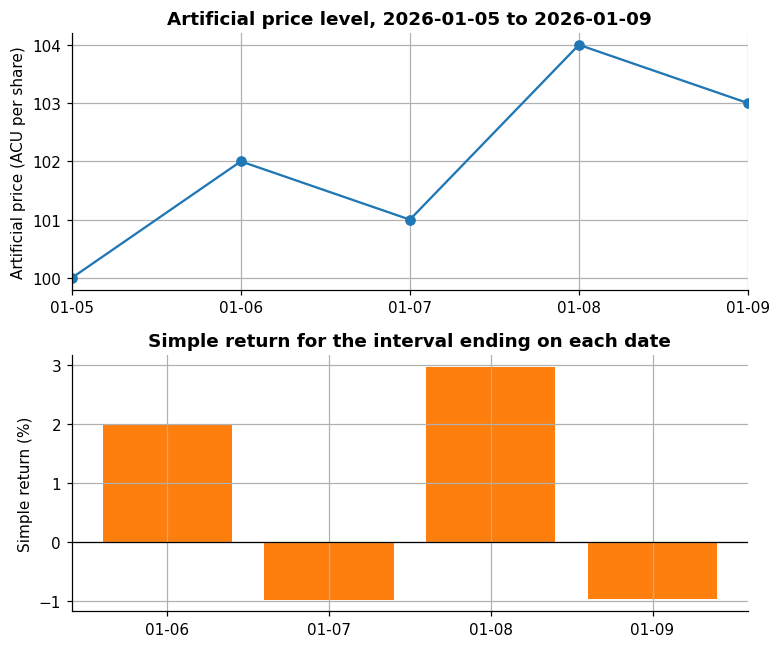

In [15]:
analysis_price = pd.Series(
    [100.0, 102.0, 101.0, 104.0, 103.0],
    index=pd.to_datetime(
        ["2026-01-05", "2026-01-06", "2026-01-07", "2026-01-08", "2026-01-09"]
    ),
    name="Analysis_Price",
)

simple_return = analysis_price.pct_change(fill_method=None).rename("Simple_Return")
simple_table = pd.concat([analysis_price, simple_return], axis=1)
display(
    simple_table.round(6).style.set_caption(
        "Artificial prices and simple returns labeled by interval end date"
    )
)

hand_return_second_date = 102.0 / 100.0 - 1
print("Hand calculation for second date:", hand_return_second_date)

twse_2330_simple_case = pd.Series(
    [320.00, 322.00],
    index=pd.to_datetime(["2020-02-24", "2020-02-25"]),
    name="TWSE_2330_Close_TWD",
)
twse_2330_simple_return = twse_2330_simple_case.pct_change(
    fill_method=None
).rename("Closing_Price_Return")
twse_2330_simple_table = pd.concat(
    [twse_2330_simple_case, twse_2330_simple_return], axis=1
)
display(
    twse_2330_simple_table.round(6).style.set_caption(
        "Real TWSE 2330 closing-price return over 2020-02-24 to 2020-02-25"
    )
)

fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.0))
analysis_price.plot(ax=axes[0], marker="o", color="tab:blue")
axes[0].set_ylabel("Artificial price (ACU per share)")
axes[0].set_title("Artificial price level, 2026-01-05 to 2026-01-09")
axes[0].set_xticks(analysis_price.index, analysis_price.index.strftime("%m-%d"))
return_percent = 100 * simple_return
axes[1].bar(return_percent.index.strftime("%m-%d"), return_percent.values, color="tab:orange")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Simple return (%)")
axes[1].set_title("Simple return for the interval ending on each date")
plt.tight_layout()
show_figure_with_alt_text(
    fig,
    "Two panels showing five artificial price levels and four simple returns labeled "
    "by interval end date from 2026-01-05 to 2026-01-09.",
)

assert pd.isna(simple_return.iloc[0])
assert np.isclose(simple_return.iloc[1], hand_return_second_date)
assert simple_return.notna().sum() == 4
assert pd.isna(twse_2330_simple_return.iloc[0])
assert np.isclose(twse_2330_simple_return.iloc[1], 322.0 / 320.0 - 1)

### Interpret the output


Five prices provide four complete holding intervals. The first row retains a missing return because no earlier price appears in the table.

The hand calculation for January 6 is `102 / 100 - 1 = 0.02`, or 2%. The upper panel shows the five artificial price levels. The lower panel places each return on its ending date.

This arithmetic does not establish that the selected endpoints are financially compatible. Confirm the asset, price field, currency, unit, and meaning of both timestamps before treating the result as an asset return.

The real closing-price return ending on 2020-02-25 is `322 / 320 - 1 = 0.00625`, or 0.625%. Its first row remains missing because 2020-02-24 is the beginning endpoint in this two-row table. The result is limited to the quoted closing prices displayed by the cited TWSE report.


### Discussion questions

1. The TWSE report gives closing prices of 320.00 on 2020-02-24 and 322.00 on 2020-02-25. Calculate the simple return and state its beginning date, ending date, decimal value, and percentage value. Then explain what holding interval a reader could wrongly infer if the return were labeled 2020-02-24 instead of 2020-02-25.
2. A calculation divides a January 6 adjusted closing price of 102 BCU by a January 5 raw closing price of 100 ACU and reports 2%. List every field definition and conversion needed before these two values can form one return. State which part of the 2% result is mathematically correct and why it still cannot be reported as an asset return from the available information.

## Issue 10 — When can a log return be calculated from two prices?


A log return is the natural logarithm of the ending price divided by the beginning price. Both prices must be strictly positive because the natural logarithm is not defined for zero or a negative real number.

Log returns add across consecutive intervals that share matching endpoints. A log return is not the percentage change in wealth. Convert it back with `exp(log return) - 1` before interpreting it as a simple return.

The code checks every artificial price before applying the logarithm. It uses the same holding intervals as Issue 9.

The real calculation uses the same TWSE 2330 closing-price endpoints as Issue 9: 320.00 on 2020-02-24 and 322.00 on 2020-02-25. Both are positive, so a log return can be calculated. The cited [TWSE daily report](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330) supports the price endpoints but does not change the mathematical interpretation of the log return.


### Before running the example


Use 100 and 102 to predict the artificial log return ending on January 6. State whether it should be above or below the 2% simple return, and confirm that all five artificial prices are positive. Then predict the log return from the real 320.00 and 322.00 endpoints and the simple return recovered from it.

,Analysis_Price,Simple_Return,Log_Return
2026-01-05 00:00:00,100.000000,nan,nan
2026-01-06 00:00:00,102.000000,0.020000,0.019803
2026-01-07 00:00:00,101.000000,-0.009804,-0.009852
2026-01-08 00:00:00,104.000000,0.029703,0.029270
2026-01-09 00:00:00,103.000000,-0.009615,-0.009662


Hand log return for second date: 0.01980262729617973


,TWSE_2330_Close_TWD,Closing_Price_Return,Log_Closing_Price_Return,Simple_Return_Recovered_From_Log
2020-02-24 00:00:00,320.000000,nan,nan,nan
2020-02-25 00:00:00,322.000000,0.006250,0.006231,0.006250


,Simple_Return,Log_Return
2026-01-05 00:00:00,nan,nan
2026-01-06 00:00:00,2.000000,1.980300
2026-01-07 00:00:00,-0.980400,-0.985200
2026-01-08 00:00:00,2.970300,2.927000
2026-01-09 00:00:00,-0.961500,-0.966200


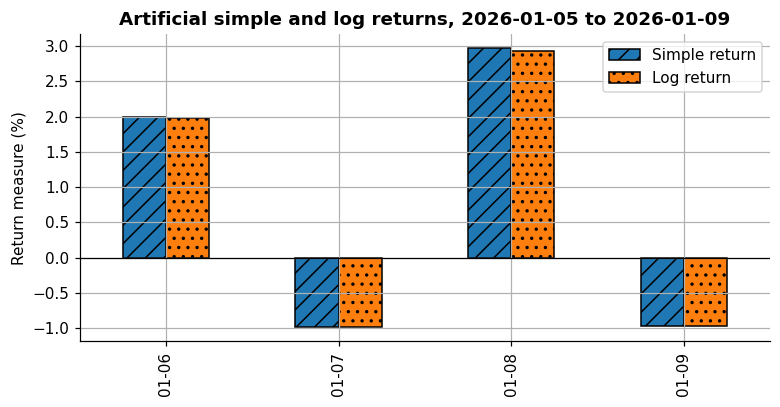

In [16]:
if not analysis_price.gt(0).all():
    raise ValueError("Log returns require positive price levels.")

log_return = np.log(analysis_price).diff().rename("Log_Return")
log_table = pd.concat([analysis_price, simple_return, log_return], axis=1)
display(
    log_table.round(6).style.set_caption(
        "Artificial prices with simple and log returns on matching intervals"
    )
)

hand_log_return = np.log(102.0 / 100.0)
print("Hand log return for second date:", hand_log_return)

twse_2330_log_return = np.log(twse_2330_simple_case).diff().rename(
    "Log_Closing_Price_Return"
)
twse_2330_log_table = pd.concat(
    [twse_2330_simple_case, twse_2330_simple_return, twse_2330_log_return],
    axis=1,
)
twse_2330_log_table["Simple_Return_Recovered_From_Log"] = np.expm1(
    twse_2330_log_table["Log_Closing_Price_Return"]
)
display(
    twse_2330_log_table.round(8).style.set_caption(
        "Real TWSE 2330 simple and log closing-price returns on one interval"
    )
)

return_comparison_percent = pd.concat([simple_return, log_return], axis=1).mul(100)
display(
    return_comparison_percent.round(4).style.set_caption(
        "Simple and log return measures shown in percentage-scaled units"
    )
)
return_comparison_plot = return_comparison_percent.dropna().copy()
return_comparison_plot.index = return_comparison_plot.index.strftime("%m-%d")
return_comparison_plot.columns = ["Simple return", "Log return"]
ax = return_comparison_plot.plot(kind="bar", edgecolor="black")
for patch_number, bar in enumerate(ax.patches):
    bar.set_hatch("//" if patch_number < len(return_comparison_plot) else "..")
ax.axhline(0, color="black", linewidth=0.8, label="_nolegend_")
ax.set_ylabel("Return measure (%)")
ax.set_title("Artificial simple and log returns, 2026-01-05 to 2026-01-09")
ax.legend()
plt.tight_layout()
show_figure_with_alt_text(
    ax.figure,
    "Grouped bars compare artificial simple and log returns on four matching intervals; "
    "each log return is close to but not equal to its simple return.",
)

assert pd.isna(log_return.iloc[0])
assert np.isclose(log_return.iloc[1], hand_log_return)
assert log_return.notna().sum() == 4
assert np.isclose(twse_2330_log_return.iloc[1], np.log(322.0 / 320.0))
assert np.isclose(
    twse_2330_log_table["Simple_Return_Recovered_From_Log"].iloc[1],
    322.0 / 320.0 - 1,
)

### Interpret the output


For January 6, the simple return is 2%, while the log return is approximately 1.9803% when multiplied by 100 for display. They are calculated from the same two prices but use different mathematical definitions.

The grouped bars use position, labels, and hatch patterns as well as color. They compare the two measures only on dates for which both exist.

For small price changes, the numerical values are close. For large changes, the difference can be substantial. A log return does not repair a zero, negative, incorrectly adjusted, or mismatched input price.

For the real TWSE interval, the simple closing-price return is 0.00625 and the log closing-price return is approximately 0.00623055. Applying `expm1` to the log return recovers 0.00625. Both results use the same positive endpoints and remain closing-price measures rather than distribution-inclusive returns.


### Discussion questions

1. For the TWSE 2330 closing prices of 320.00 and 322.00, calculate the simple return and log return without rounding. Convert the log return back with `exp(log return) - 1`, and explain why the log-return value multiplied by 100 should not replace the simple percentage change in investor wealth.
2. A recorded price moves from 5 to negative 2. Show which part of the log-return formula is undefined. Then state what must be learned about the asset, contract, price field, and return definition before replacing the log return with another calculation. Do not assume that a negative recorded price is automatically a data error.

## Issue 11 — How can we check that simple and log returns use the same endpoints?


When simple and log returns use the same two positive prices, converting the log return with `exp(log return) - 1` must reproduce the simple return. This equality checks the formulas, source values, and interval alignment used by the code.

A passed equality does not show that the prices came from the correct asset or field. It also does not show that a corporate action was handled correctly. Those facts require the data checks from Issues 1–8.

The artificial example converts every log return back to a simple return and reports the largest absolute numerical difference.

The real check uses the TWSE 2330 closing-price return and log return calculated in Issues 9–10 from 320.00 on 2020-02-24 and 322.00 on 2020-02-25. The [official TWSE report](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330) also reports 318.50 on 2020-02-26; that third value is used in a discussion question to show how one wrong endpoint breaks the reconciliation.


### Before running the example


Predict the largest artificial reconciliation difference. State whether you expect an exact printed zero or a very small floating-point difference, and explain why the check must use unrounded values. Then predict whether the real TWSE simple return and converted log return will pass the same tolerance when they use identical endpoints.

In [17]:
simple_from_log = np.expm1(log_return).rename("Simple_From_Log")
reconciliation = pd.concat(
    [simple_return, log_return, simple_from_log],
    axis=1,
)
reconciliation["Absolute_Difference"] = (
    reconciliation["Simple_Return"] - reconciliation["Simple_From_Log"]
).abs()

display(
    reconciliation.round(12).style.set_caption(
        "Reconciliation of simple and log returns on identical artificial intervals"
    )
)
max_difference = reconciliation["Absolute_Difference"].max()
print("Maximum reconciliation difference:", max_difference)

twse_reconciliation = pd.DataFrame(
    {
        "Simple_Return": [twse_2330_simple_return.iloc[1]],
        "Log_Return": [twse_2330_log_return.iloc[1]],
    },
    index=pd.to_datetime(["2020-02-25"]),
)
twse_reconciliation["Simple_From_Log"] = np.expm1(
    twse_reconciliation["Log_Return"]
)
twse_reconciliation["Absolute_Difference"] = (
    twse_reconciliation["Simple_Return"]
    - twse_reconciliation["Simple_From_Log"]
).abs()
display(
    twse_reconciliation.round(12).style.set_caption(
        "Real TWSE 2330 reconciliation on the 2020-02-24 to 2020-02-25 interval"
    )
)

assert max_difference < 1e-12
assert twse_reconciliation["Absolute_Difference"].max() < 1e-12

,Simple_Return,Log_Return,Simple_From_Log,Absolute_Difference
2026-01-05 00:00:00,nan,nan,nan,nan
2026-01-06 00:00:00,0.020000,0.019803,0.020000,0.000000
2026-01-07 00:00:00,-0.009804,-0.009852,-0.009804,0.000000
2026-01-08 00:00:00,0.029703,0.029270,0.029703,0.000000
2026-01-09 00:00:00,-0.009615,-0.009662,-0.009615,0.000000


Maximum reconciliation difference: 8.708311849403572e-16


,Simple_Return,Log_Return,Simple_From_Log,Absolute_Difference
2020-02-25 00:00:00,0.006250,0.006231,0.006250,0.000000


### Interpret the output


The maximum difference is smaller than `1e-12`, which is the stated tolerance in this example. The conversion therefore reproduces the stored simple returns to the checked numerical precision.

If the difference were larger, inspect the two price columns, date endpoints, missing-value treatment, and percent conversion. Do not solve a large difference by increasing the tolerance before locating its cause.

This check compares calculations only. It does not establish that the artificial prices represent real or investable market values.

The real TWSE row also reconciles within the stated tolerance because both formulas use 320.00 and 322.00. The result confirms numerical and interval consistency for this calculation. It does not prove that another field, another date pair, or a cash-inclusive measure would reconcile to the same values.


### Discussion questions

1. A student calculates the TWSE simple return from 320.00 on 2020-02-24 to 322.00 on 2020-02-25, but calculates the log return from 322.00 on 2020-02-25 to 318.50 on 2020-02-26. Build the endpoint table needed to reveal the mismatch, calculate both returns, and explain why increasing the numerical tolerance would conceal an interval error rather than reconcile the formulas.
2. A report displays simple and log returns rounded to two decimal percentage points, then tries to reconcile the rounded columns. Explain why the displayed numbers can fail even when the unrounded calculations are correct. Specify which unrounded values, transformation, and tolerance should be saved for the check, and which rounded values may be used only for presentation.

## Issue 12 — How do adjacent simple returns produce terminal wealth?


Each simple return applies to the wealth available at the beginning of its own interval. After one interval changes wealth, the next return applies to that new amount.

To combine adjacent simple returns, multiply their growth factors, `1 + return`, and subtract one from the final product. Adding simple returns treats every return as though it applied to the original wealth and therefore does not reproduce the actual wealth path.

The artificial example uses three consecutive periods and one initial wealth unit. The periods have no calendar dates, so the output explains the compounding calculation but does not describe an annual or market return.

The real example uses four consecutive TWSE 2330 closing prices from the [February 2020 daily report](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330): 320.00, 322.00, 318.50, and 316.00 from February 24 through February 27. The three adjacent closing-price returns must compound to the final-to-initial price ratio. No cash distribution is added.


### Before running the example


Predict the result of adding the three artificial returns and the result of compounding their growth factors. State which result should equal the terminal change in one initial unit of wealth. Then predict whether the real TWSE compounded return or the sum of its adjacent returns will match `316 / 320 - 1`.

,Simple_Return
Period 1,0.100000
Period 2,-0.100000
Period 3,0.050000


Added simple returns: 0.05
Compounded simple return: 0.03950000000000009


,Simple_Return,Growth_Factor,Compounded_Wealth,Added_Return_Approximation
Period 1,0.100000,1.100000,1.100000,1.100000
Period 2,-0.100000,0.900000,0.990000,1.000000
Period 3,0.050000,1.050000,1.039500,1.050000


,TWSE_2330_Close_TWD,Closing_Price_Return,Wealth_From_One
2020-02-24 00:00:00,320.000000,nan,1.000000
2020-02-25 00:00:00,322.000000,0.006250,1.006250
2020-02-26 00:00:00,318.500000,-0.010870,0.995313
2020-02-27 00:00:00,316.000000,-0.007849,0.987500


Calculation,Return_decimal
Added adjacent returns,-0.012469
Compounded adjacent returns,-0.012500
Final close divided by initial close minus one,-0.012500


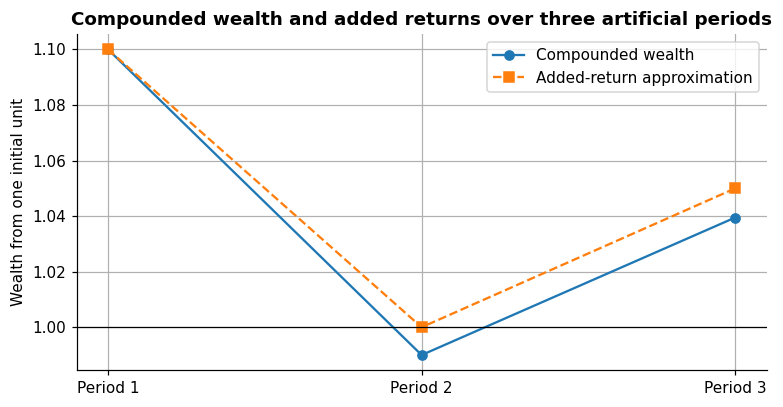

In [18]:
period_returns = pd.Series(
    [0.10, -0.10, 0.05],
    index=["Period 1", "Period 2", "Period 3"],
    name="Simple_Return",
)

added_return = period_returns.sum()
compounded_return = (1.0 + period_returns).prod() - 1.0

display(
    period_returns.to_frame().style.set_caption(
        "Three consecutive artificial simple returns"
    )
)
print("Added simple returns:", added_return)
print("Compounded simple return:", compounded_return)

compounding_table = period_returns.to_frame()
compounding_table["Growth_Factor"] = 1.0 + compounding_table["Simple_Return"]
compounding_table["Compounded_Wealth"] = compounding_table["Growth_Factor"].cumprod()
compounding_table["Added_Return_Approximation"] = 1.0 + compounding_table["Simple_Return"].cumsum()
display(
    compounding_table.round(4).style.set_caption(
        "Growth factors and wealth after each artificial period"
    )
)

twse_2330_compounding_prices = pd.Series(
    [320.00, 322.00, 318.50, 316.00],
    index=pd.to_datetime(
        ["2020-02-24", "2020-02-25", "2020-02-26", "2020-02-27"]
    ),
    name="TWSE_2330_Close_TWD",
)
twse_2330_compounding_returns = twse_2330_compounding_prices.pct_change(
    fill_method=None
).rename("Closing_Price_Return")
twse_2330_compounded_return = (
    1.0 + twse_2330_compounding_returns.dropna()
).prod() - 1.0
twse_2330_added_return = twse_2330_compounding_returns.sum()
twse_2330_endpoint_return = (
    twse_2330_compounding_prices.iloc[-1]
    / twse_2330_compounding_prices.iloc[0]
    - 1.0
)
twse_2330_compounding_table = pd.concat(
    [twse_2330_compounding_prices, twse_2330_compounding_returns], axis=1
)
twse_2330_compounding_table["Wealth_From_One"] = (
    1.0 + twse_2330_compounding_returns.fillna(0.0)
).cumprod()
display(
    twse_2330_compounding_table.round(8).style.set_caption(
        "Real TWSE 2330 adjacent closing-price returns and compounded wealth"
    )
)
display(
    pd.DataFrame(
        {
            "Calculation": [
                "Added adjacent returns",
                "Compounded adjacent returns",
                "Final close divided by initial close minus one",
            ],
            "Return_decimal": [
                twse_2330_added_return,
                twse_2330_compounded_return,
                twse_2330_endpoint_return,
            ],
        }
    ).round(8).style.set_caption(
        "Three calculations for the real 2020-02-24 to 2020-02-27 interval"
    ).hide(axis="index")
)

fig, ax = plt.subplots()
ax.plot(
    compounding_table.index,
    compounding_table["Compounded_Wealth"],
    marker="o",
    linestyle="-",
    label="Compounded wealth",
)
ax.plot(
    compounding_table.index,
    compounding_table["Added_Return_Approximation"],
    marker="s",
    linestyle="--",
    label="Added-return approximation",
)
ax.axhline(1.0, color="black", linewidth=0.8)
ax.set_ylabel("Wealth from one initial unit")
ax.set_title("Compounded wealth and added returns over three artificial periods")
ax.legend(["Compounded wealth", "Added-return approximation"])
plt.tight_layout()
show_figure_with_alt_text(
    fig,
    "Two line paths compare compounded wealth with the result of adding returns over "
    "three artificial periods; the paths finish at 1.0395 and 1.05.",
)

manual_terminal_wealth = 1.0 * 1.10 * 0.90 * 1.05
assert np.isclose(compounded_return, manual_terminal_wealth - 1.0)
assert not np.isclose(added_return, compounded_return)
assert np.isclose(twse_2330_compounded_return, twse_2330_endpoint_return)
assert not np.isclose(twse_2330_added_return, twse_2330_endpoint_return)

### Interpret the output


Adding 10%, negative 10%, and 5% gives 5%. Compounding gives `1.10 × 0.90 × 1.05 - 1 = 0.0395`, or 3.95%.

After the first two periods, wealth equals `1.10 × 0.90 = 0.99`. Equal positive and negative percentage returns do not cancel because the negative return applies after wealth has increased.

The chart uses different markers and line styles for the compounded path and the added-return calculation. The compounding result is meaningful only when the returns form one ordered chain of adjacent holding intervals with no unexplained gap or overlap.

For the real TWSE closes, compounding the three adjacent returns gives negative 1.25%, exactly matching `316 / 320 - 1` within numerical precision. Adding the three returns gives a different value. This check supports the arithmetic for this closing-price path only; it does not add distributions or costs.


### Discussion questions

1. Using the TWSE 2330 closes 320.00, 322.00, 318.50, and 316.00, calculate all three adjacent simple returns without rounding. Compare their sum, their compounded product, and `316 / 320 - 1`. Explain why only one of the first two calculations must equal the full-interval closing-price return.
2. A table contains a 5% return from January 1 to January 2 and a negative 2% return from January 3 to January 4, but it contains no return linking January 2 to January 3. Calculate the product of the two listed growth factors, then state exactly which full-period return that product cannot represent. Identify the missing endpoint information required before reporting a January 1-to-January 4 compounded return.

## Issue 13 — What does a wealth path show that terminal return does not?


A wealth path starts with a stated amount and applies each return in chronological order. Starting at one makes every later value interpretable as the value of one initial unit under the stated price, reinvestment, cost, and cash-flow assumptions.

The path shows when wealth rises, falls, and recovers. A terminal return reports only the difference between the first and final values and cannot show the losses experienced between them.

For this artificial price-only series, there are no external deposits, withdrawals, distributions, or costs. Under those conditions, terminal wealth calculated from consecutive simple returns must equal the final price divided by the initial price.

The real example uses the same four TWSE 2330 closing prices as Issue 12. The [TWSE report](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330) supports the endpoints. Normalizing the closing-price path to one shows an initial rise followed by two declines, even though the terminal closing-price return alone reports only the final loss.


### Before running the example


Predict the terminal wealth from the first and last artificial prices. Then predict whether the artificial wealth-from-returns line and normalized-price line should coincide. For the real TWSE closes, predict the four wealth values and identify whether terminal wealth alone will reveal the initial increase.

,Analysis_Price,Simple_Return,Wealth_Index
2026-01-05 00:00:00,100.000000,nan,1.000000
2026-01-06 00:00:00,102.000000,0.020000,1.020000
2026-01-07 00:00:00,101.000000,-0.009804,1.010000
2026-01-08 00:00:00,104.000000,0.029703,1.040000
2026-01-09 00:00:00,103.000000,-0.009615,1.030000


Terminal wealth from returns: 1.03
Endpoint price ratio: 1.03


,TWSE_2330_Close_TWD,Closing_Price_Return,Wealth_From_Returns,Normalized_Close
2020-02-24 00:00:00,320.000000,nan,1.000000,1.000000
2020-02-25 00:00:00,322.000000,0.006250,1.006250,1.006250
2020-02-26 00:00:00,318.500000,-0.010870,0.995313,0.995313
2020-02-27 00:00:00,316.000000,-0.007849,0.987500,0.987500


,Wealth_from_returns,Normalized_price
2026-01-05 00:00:00,1.000000,1.000000
2026-01-06 00:00:00,1.020000,1.020000
2026-01-07 00:00:00,1.010000,1.010000
2026-01-08 00:00:00,1.040000,1.040000
2026-01-09 00:00:00,1.030000,1.030000


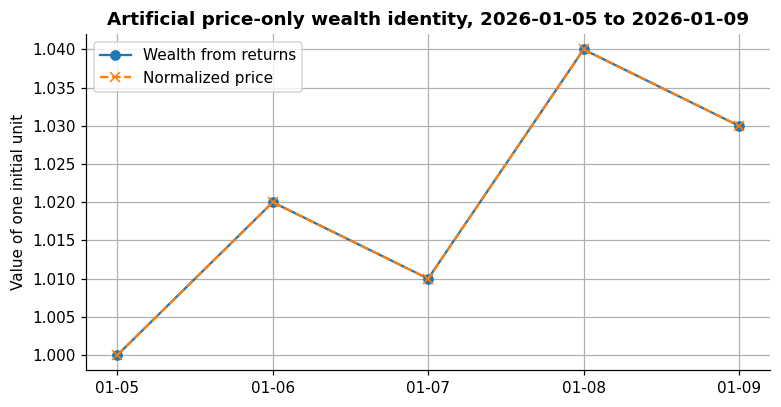

In [19]:
if simple_return.iloc[1:].isna().any():
    raise ValueError("An internal return is missing; do not fill it when building wealth.")

wealth_growth = (1.0 + simple_return).copy()
wealth_growth.iloc[0] = 1.0
wealth_index = wealth_growth.cumprod().rename("Wealth_Index")
wealth_table = pd.concat([analysis_price, simple_return, wealth_index], axis=1)
display(
    wealth_table.round(6).style.set_caption(
        "Artificial price, return, and wealth path from one initial unit"
    )
)

terminal_from_returns = wealth_index.iloc[-1]
terminal_from_prices = analysis_price.iloc[-1] / analysis_price.iloc[0]

print("Terminal wealth from returns:", terminal_from_returns)
print("Endpoint price ratio:", terminal_from_prices)

twse_2330_wealth_from_returns = (
    1.0 + twse_2330_compounding_returns.fillna(0.0)
).cumprod().rename("Wealth_From_Returns")
twse_2330_normalized_close = (
    twse_2330_compounding_prices / twse_2330_compounding_prices.iloc[0]
).rename("Normalized_Close")
twse_2330_wealth_path = pd.concat(
    [
        twse_2330_compounding_prices,
        twse_2330_compounding_returns,
        twse_2330_wealth_from_returns,
        twse_2330_normalized_close,
    ],
    axis=1,
)
display(
    twse_2330_wealth_path.round(8).style.set_caption(
        "Real TWSE 2330 closing-price wealth path from one unit on 2020-02-24"
    )
)

wealth_identity_plot = pd.DataFrame(
    {
        "Wealth_from_returns": wealth_index,
        "Normalized_price": analysis_price / analysis_price.iloc[0],
    }
)
display(
    wealth_identity_plot.round(6).style.set_caption(
        "Wealth from returns and normalized price under matching assumptions"
    )
)
fig, ax = plt.subplots()
ax.plot(
    wealth_identity_plot.index,
    wealth_identity_plot["Wealth_from_returns"],
    marker="o",
    linestyle="-",
    label="Wealth from returns",
)
ax.plot(
    wealth_identity_plot.index,
    wealth_identity_plot["Normalized_price"],
    marker="x",
    linestyle="--",
    label="Normalized price",
)
ax.set_ylabel("Value of one initial unit")
ax.set_title("Artificial price-only wealth identity, 2026-01-05 to 2026-01-09")
ax.set_xticks(wealth_identity_plot.index, wealth_identity_plot.index.strftime("%m-%d"))
ax.legend()
plt.tight_layout()
show_figure_with_alt_text(
    fig,
    "Artificial wealth from consecutive returns overlaps the normalized price path, "
    "moving from 1.00 to 1.03 between 2026-01-05 and 2026-01-09.",
)

assert np.isclose(wealth_index.iloc[0], 1.0)
assert np.isclose(terminal_from_returns, terminal_from_prices)
assert np.allclose(
    twse_2330_wealth_path["Wealth_From_Returns"],
    twse_2330_wealth_path["Normalized_Close"],
)
assert np.isclose(twse_2330_wealth_path["Wealth_From_Returns"].iloc[-1], 0.9875)

### Interpret the output


The first growth factor is set to one only to initialize wealth at one on January 5. The first return remains missing in the table. The code raises an error instead of filling any missing return after the first row.

Terminal wealth from the returns equals the final price divided by the initial price. The normalized-price and wealth lines overlap under the artificial price-only assumptions. Different markers and line styles show that two separately calculated series are present even where they coincide.

A deposit, withdrawal, distribution, transaction cost, or incompatible price adjustment would break this simple identity or require a different return calculation.

The real TWSE path moves from 1.000000 to 1.006250, then to 0.995313, and finally to 0.987500. Its terminal closing-price return is negative 1.25%, but that single number omits the initial rise and the dates of the subsequent declines. No trading cost, dividend, or portfolio decision is included.


### Discussion questions

1. Using the TWSE 2330 closes 320.00, 322.00, 318.50, and 316.00, construct the wealth path from one initial unit and identify every date on which wealth is above or below one. State what the terminal return reveals and which changes in direction it hides.
2. An asset price rises from 100 to 110, while the investor deposits 50 into the account during the interval. The final account value is 160. Compare `160 / 100 - 1` with the asset price return. Identify the external cash flow and explain why the account-value ratio cannot be reported as the asset's investment return without a cash-flow-adjusted calculation.

## Issue 14 — Which average describes one-period returns and which reproduces compounded wealth?


The arithmetic mean adds the periodic returns and divides by the number of valid intervals. It answers the question: what was the average return across these individual intervals?

The geometric mean is the constant return that would reproduce the same terminal wealth over the same number of intervals. It answers the question: what constant per-period growth rate matches the observed compounded path?

The geometric mean requires every growth factor, `1 + return`, to be positive for this real-valued calculation. For simple returns above negative 100%, it cannot exceed the arithmetic mean. The artificial example uses four daily intervals but does not annualize either result.

The real example uses the three adjacent TWSE 2330 closing-price returns from February 24–27, 2020. The [official daily report](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330) provides the closing-price endpoints. The calculation reports a mean per observed holding interval; it does not annualize the result or treat four calendar dates as four return intervals.


### Before running the example


Predict which mean will be larger for the four unequal artificial returns. Also predict whether the artificial geometric mean, when repeated over four intervals, will reproduce terminal wealth. Then make the same predictions for the three real TWSE closing-price returns and state their correct interval count.

,Value,Unit
Arithmetic_mean,0.007571,decimal return per period
Geometric_mean,0.007417,decimal return per period
Observed_terminal_wealth,1.030000,wealth
Wealth_from_geometric_mean,1.030000,wealth


,Value,Unit
Arithmetic_mean,-0.004156,decimal return per observed interval
Geometric_mean,-0.004184,decimal return per observed interval
Observed_terminal_wealth,0.987500,wealth from one initial unit
Wealth_from_geometric_mean,0.987500,wealth from one initial unit


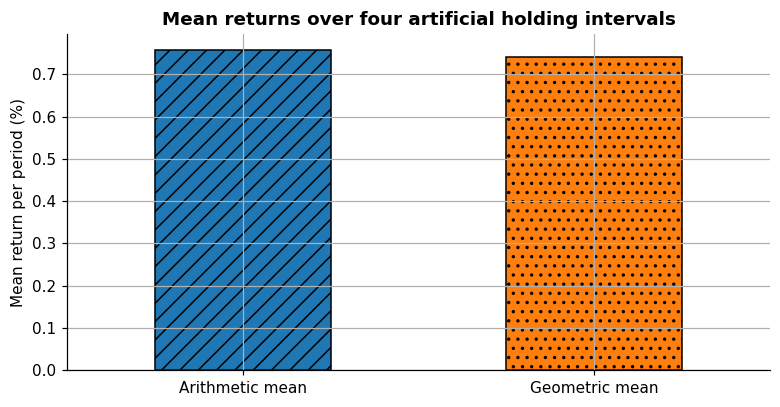

In [20]:
valid_returns = simple_return.dropna()
if valid_returns.le(-1.0).any():
    raise ValueError("This geometric-mean calculation requires every return to exceed -100%.")

arithmetic_mean = valid_returns.mean()
geometric_mean = (1.0 + valid_returns).prod() ** (1.0 / len(valid_returns)) - 1.0

reproduced_terminal_wealth = (1.0 + geometric_mean) ** len(valid_returns)
observed_terminal_wealth = (1.0 + valid_returns).prod()

summary_means = pd.DataFrame(
    {
        "Value": [
            arithmetic_mean,
            geometric_mean,
            observed_terminal_wealth,
            reproduced_terminal_wealth,
        ],
        "Unit": ["decimal return per period", "decimal return per period", "wealth", "wealth"],
    },
    index=[
        "Arithmetic_mean",
        "Geometric_mean",
        "Observed_terminal_wealth",
        "Wealth_from_geometric_mean",
    ],
)
display(
    summary_means.round(8).style.set_caption(
        "Arithmetic mean, geometric mean, and wealth identity for four artificial intervals"
    )
)

twse_2330_valid_returns = twse_2330_compounding_returns.dropna()
twse_2330_arithmetic_mean = twse_2330_valid_returns.mean()
twse_2330_geometric_mean = (
    (1.0 + twse_2330_valid_returns).prod()
    ** (1.0 / len(twse_2330_valid_returns))
    - 1.0
)
twse_2330_observed_wealth = (1.0 + twse_2330_valid_returns).prod()
twse_2330_reproduced_wealth = (
    1.0 + twse_2330_geometric_mean
) ** len(twse_2330_valid_returns)
twse_2330_mean_table = pd.DataFrame(
    {
        "Value": [
            twse_2330_arithmetic_mean,
            twse_2330_geometric_mean,
            twse_2330_observed_wealth,
            twse_2330_reproduced_wealth,
        ],
        "Unit": [
            "decimal return per observed interval",
            "decimal return per observed interval",
            "wealth from one initial unit",
            "wealth from one initial unit",
        ],
    },
    index=[
        "Arithmetic_mean",
        "Geometric_mean",
        "Observed_terminal_wealth",
        "Wealth_from_geometric_mean",
    ],
)
display(
    twse_2330_mean_table.round(10).style.set_caption(
        "Real TWSE 2330 mean returns and wealth identity over three intervals"
    )
)

mean_comparison_percent = pd.Series(
    {"Arithmetic mean": 100 * arithmetic_mean, "Geometric mean": 100 * geometric_mean}
)
ax = mean_comparison_percent.plot(
    kind="bar",
    color=["tab:blue", "tab:orange"],
    edgecolor="black",
    rot=0,
)
ax.patches[0].set_hatch("//")
ax.patches[1].set_hatch("..")
ax.set_ylabel("Mean return per period (%)")
ax.set_title("Mean returns over four artificial holding intervals")
plt.tight_layout()
show_figure_with_alt_text(
    ax.figure,
    "Two bars compare arithmetic and geometric mean returns over four artificial intervals; "
    "the geometric mean bar is slightly lower.",
)

assert geometric_mean <= arithmetic_mean + 1e-15
assert np.isclose(reproduced_terminal_wealth, observed_terminal_wealth)
assert twse_2330_geometric_mean <= twse_2330_arithmetic_mean + 1e-15
assert np.isclose(twse_2330_reproduced_wealth, twse_2330_observed_wealth)

### Interpret the output


The arithmetic mean is the average of the four stored one-period returns. The geometric mean is lower because the returns vary across intervals.

Raising one plus the geometric mean to the fourth power reproduces the observed terminal wealth. The arithmetic mean does not generally reproduce that wealth identity.

The summary table separates return units from wealth units. The bar labels and hatch patterns distinguish the two mean returns without relying only on color. Neither result is annualized because the example has not stated an annualization rule.

For the real TWSE path, the arithmetic and geometric means are both negative, and the geometric mean is slightly lower. Repeating one plus the geometric mean for three intervals reproduces terminal wealth of 0.9875. The arithmetic mean answers a different question and is not used to reconstruct that wealth.


### Discussion questions

1. Calculate the three TWSE 2330 returns from closes 320.00, 322.00, 318.50, and 316.00. Then calculate their arithmetic mean, geometric mean, and terminal wealth. Verify which mean reproduces the terminal wealth when repeated three times, and explain why the number of prices is not the number of return intervals.
2. Fund A earns 10% in both periods. Fund B earns 30% and then loses 10%. Both funds have an arithmetic mean of 10%. Calculate each terminal wealth and geometric mean. State which statistic reveals the difference in compounded growth and why the comparison must still report both underlying return paths.

## Issue 15 — Do the date strings produce one correctly ordered row per intended observation?


Return calculations require correctly parsed dates in chronological order. Sorting date text as ordinary characters can produce the wrong order. A date such as `03/04/2026` can also mean March 4 or April 3 unless the source states its format.

Two rows with the same asset, field, and timestamp would create two possible endpoint values. Sorting does not decide which row is correct, and averaging the values would create a new observation not reported by the source.

The artificial input is not sorted and contains two prices for March 3. The code preserves the original row order, parses the stated `YYYY-MM-DD` format, counts repeated dates, and creates a separate sorted view. It does not select or combine the repeated prices.

The real example uses the date strings `109/02/24` through `109/02/27` displayed in the [TWSE report for security 2330](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330). In this source, year 109 is a Republic of China year and corresponds to 2020 after adding 1911. The code parses the three components explicitly, converts the year, and checks the resulting order and uniqueness. It does not ask a general date parser to guess the calendar.


### Before running the example


Predict whether the artificial input is already sorted and how many dates occur more than once beyond their first occurrence. Do not choose between the two March 3 prices. Then convert ROC year 109 to its Gregorian year and predict the order and repeated-date count of the real TWSE subset.

In [21]:
date_records = pd.DataFrame(
    {
        "Date_text": ["2026-03-03", "2026-03-02", "2026-03-03", "2026-03-05"],
        "Price": [51.0, 50.0, 51.2, 52.0],
    }
)
date_records["Parsed_Date"] = pd.to_datetime(date_records["Date_text"], format="%Y-%m-%d")

date_audit = pd.Series(
    {
        "rows": len(date_records),
        "parse_failures": int(date_records["Parsed_Date"].isna().sum()),
        "duplicate_dates_beyond_first": int(date_records["Parsed_Date"].duplicated().sum()),
        "input_is_sorted": bool(date_records["Parsed_Date"].is_monotonic_increasing),
    }
)

display(
    date_records.style.set_caption(
        "Artificial input rows in their original order"
    ).hide(axis="index")
)
display(
    date_audit.rename("Result").to_frame().style.set_caption(
        "Date parsing, repeated-date, and input-order checks"
    )
)
display(
    date_records.sort_values("Parsed_Date").style.set_caption(
        "Sorted view; repeated March 3 rows remain unresolved"
    ).hide(axis="index")
)

twse_roc_date_records = pd.DataFrame(
    {
        "TWSE_Date_text": ["109/02/24", "109/02/25", "109/02/26", "109/02/27"],
        "Close_TWD": [320.00, 322.00, 318.50, 316.00],
    }
)
twse_date_parts = twse_roc_date_records["TWSE_Date_text"].str.split(
    "/", expand=True
).astype(int)
twse_roc_date_records["Parsed_Gregorian_Date"] = pd.to_datetime(
    {
        "year": twse_date_parts[0] + 1911,
        "month": twse_date_parts[1],
        "day": twse_date_parts[2],
    }
)
twse_date_audit = pd.Series(
    {
        "rows": len(twse_roc_date_records),
        "parse_failures": int(
            twse_roc_date_records["Parsed_Gregorian_Date"].isna().sum()
        ),
        "duplicate_dates_beyond_first": int(
            twse_roc_date_records["Parsed_Gregorian_Date"].duplicated().sum()
        ),
        "parsed_dates_are_sorted": bool(
            twse_roc_date_records["Parsed_Gregorian_Date"].is_monotonic_increasing
        ),
    }
)
display(
    twse_roc_date_records.style.set_caption(
        "Real TWSE date strings converted explicitly from ROC year to Gregorian date"
    ).hide(axis="index")
)
display(
    twse_date_audit.rename("Result").to_frame().style.set_caption(
        "Parsing, order, and repeated-date checks for the real TWSE subset"
    )
)

assert date_audit["parse_failures"] == 0
assert date_audit["duplicate_dates_beyond_first"] == 1
assert not date_audit["input_is_sorted"]
assert twse_date_audit["parse_failures"] == 0
assert twse_date_audit["duplicate_dates_beyond_first"] == 0
assert twse_date_audit["parsed_dates_are_sorted"]
assert twse_roc_date_records["Parsed_Gregorian_Date"].iloc[0] == pd.Timestamp(
    "2020-02-24"
)

Date_text,Price,Parsed_Date
2026-03-03,51.000000,2026-03-03 00:00:00
2026-03-02,50.000000,2026-03-02 00:00:00
2026-03-03,51.200000,2026-03-03 00:00:00
2026-03-05,52.000000,2026-03-05 00:00:00


,Result
rows,4
parse_failures,0
duplicate_dates_beyond_first,1
input_is_sorted,False


Date_text,Price,Parsed_Date
2026-03-02,50.000000,2026-03-02 00:00:00
2026-03-03,51.000000,2026-03-03 00:00:00
2026-03-03,51.200000,2026-03-03 00:00:00
2026-03-05,52.000000,2026-03-05 00:00:00


TWSE_Date_text,Close_TWD,Parsed_Gregorian_Date
109/02/24,320.000000,2020-02-24 00:00:00
109/02/25,322.000000,2020-02-25 00:00:00
109/02/26,318.500000,2020-02-26 00:00:00
109/02/27,316.000000,2020-02-27 00:00:00


,Result
rows,4
parse_failures,0
duplicate_dates_beyond_first,0
parsed_dates_are_sorted,True


### Interpret the output


The input dates parse without an error, but the original rows are not in chronological order. One March 3 row appears beyond the first March 3 row.

The sorted view places the dates in order and retains both March 3 prices, 51.0 and 51.2. Choosing the first, last, average, minimum, or maximum would produce a different price history. The source record must identify whether the rows refer to different assets, sessions, update versions, or an actual duplicate.

The four real TWSE strings convert to 2020-02-24 through 2020-02-27. They contain no parsing failure or repeated date and are already ordered after explicit conversion. This result depends on the calendar meaning stated by the source; merely accepting a string as a date would not prove that the correct year system was used.


### Discussion questions

1. The two March 3 prices are 51.0 and 51.2, and the March 5 price is 52.0. Calculate the March 3-to-March 5 return once with 51.0 and once with 51.2. Report the numerical difference. Then list the asset, field, timestamp, session, provider update, and source-row information needed before either repeated row can be selected.
2. The TWSE strings `109/02/24` and `109/02/25` accompany closes of 320.00 and 322.00. Write the explicit year, month, and day conversion that produces 2020-02-24 and 2020-02-25. Then explain how a parser that silently treats `109` as a Gregorian year could preserve the price return while making every time-based merge and market-calendar check wrong.

## Issue 16 — Which rows are missing, unchanged, nonpositive, infinite, or unusually large?


A missing value contains no reported price. An unchanged price equals the preceding reported price, but that equality alone does not show whether trading was inactive or the data stopped updating.

A zero or negative value cannot enter the positive-price log-return calculation used in Issue 10. A zero can indicate total loss, a placeholder, a unit problem, or a source error. The surrounding asset and field definitions determine which explanation is possible.

A finite return above a chosen review threshold is not automatically wrong. It can reflect a market event, corporate action, currency change, or data error. The artificial example preserves every row and adds separate Boolean columns. Its 25% threshold is a classroom setting used only to locate a row for review.

The real example applies the same checks and the same 25% review threshold to the four TWSE 2330 closing prices from February 24–27, 2020. The [TWSE report](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330) supplies the values. A zero flag count means only that these checks did not detect their stated conditions in this four-row subset.


### Before running the example


Inspect the seven artificial prices. Predict which date will be marked missing, nonpositive, unchanged, infinite, and above the finite 25% threshold. Treat these as five separate checks. Then predict the flag counts for the four real TWSE closing prices under the same definitions and threshold.

,Price,missing,nonpositive,unchanged_from_previous,raw_simple_return,infinite_return,finite_extreme_return
2026-04-01 00:00:00,100.000000,False,False,False,nan,False,False
2026-04-02 00:00:00,100.000000,False,False,True,0.000000,False,False
2026-04-03 00:00:00,nan,True,False,False,nan,False,False
2026-04-06 00:00:00,0.000000,False,True,False,nan,False,False
2026-04-07 00:00:00,150.000000,False,False,False,inf,True,False
2026-04-08 00:00:00,149.000000,False,False,False,-0.006667,False,False
2026-04-09 00:00:00,210.000000,False,False,False,0.409396,False,True


,Flagged_rows
Diagnostic flag,
missing,1
nonpositive,1
unchanged_from_previous,1
infinite_return,1
finite_extreme_return,1


,Close_TWD,missing,nonpositive,unchanged_from_previous,raw_simple_return,infinite_return,finite_extreme_return
2020-02-24 00:00:00,320.000000,False,False,False,nan,False,False
2020-02-25 00:00:00,322.000000,False,False,False,0.006250,False,False
2020-02-26 00:00:00,318.500000,False,False,False,-0.010870,False,False
2020-02-27 00:00:00,316.000000,False,False,False,-0.007849,False,False


,Flagged_rows
Check,
missing,0
nonpositive,0
unchanged_from_previous,0
infinite_return,0
finite_extreme_return,0


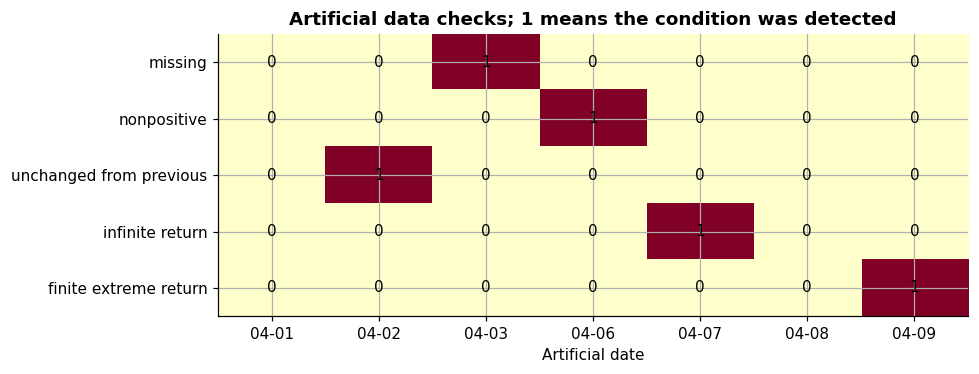

In [22]:
quality_prices = pd.Series(
    [100.0, 100.0, np.nan, 0.0, 150.0, 149.0, 210.0],
    index=pd.to_datetime(
        [
            "2026-04-01",
            "2026-04-02",
            "2026-04-03",
            "2026-04-06",
            "2026-04-07",
            "2026-04-08",
            "2026-04-09",
        ]
    ),
    name="Price",
)

quality_audit = quality_prices.to_frame()
quality_audit["missing"] = quality_audit["Price"].isna()
quality_audit["nonpositive"] = quality_audit["Price"].notna() & quality_audit["Price"].le(0)
quality_audit["unchanged_from_previous"] = quality_audit["Price"].eq(quality_audit["Price"].shift(1))
quality_audit["raw_simple_return"] = quality_audit["Price"].pct_change(fill_method=None)
quality_audit["infinite_return"] = np.isinf(quality_audit["raw_simple_return"])
quality_audit["finite_extreme_return"] = (
    np.isfinite(quality_audit["raw_simple_return"])
    & quality_audit["raw_simple_return"].abs().gt(0.25)
)

display(
    quality_audit.style.set_caption(
        "Artificial prices, raw returns, and separate data-review flags"
    )
)
quality_flag_columns = [
    "missing",
    "nonpositive",
    "unchanged_from_previous",
    "infinite_return",
    "finite_extreme_return",
]
quality_flag_summary = (
    quality_audit[quality_flag_columns]
    .sum()
    .rename("Flagged_rows")
    .rename_axis("Diagnostic flag")
    .to_frame()
)
display(
    quality_flag_summary.style.set_caption(
        "Number of artificial dates detected by each check"
    )
)

twse_quality_audit = twse_2330_compounding_prices.to_frame(name="Close_TWD")
twse_quality_audit["missing"] = twse_quality_audit["Close_TWD"].isna()
twse_quality_audit["nonpositive"] = (
    twse_quality_audit["Close_TWD"].notna()
    & twse_quality_audit["Close_TWD"].le(0)
)
twse_quality_audit["unchanged_from_previous"] = twse_quality_audit[
    "Close_TWD"
].eq(twse_quality_audit["Close_TWD"].shift(1))
twse_quality_audit["raw_simple_return"] = twse_quality_audit[
    "Close_TWD"
].pct_change(fill_method=None)
twse_quality_audit["infinite_return"] = np.isinf(
    twse_quality_audit["raw_simple_return"]
)
twse_quality_audit["finite_extreme_return"] = (
    np.isfinite(twse_quality_audit["raw_simple_return"])
    & twse_quality_audit["raw_simple_return"].abs().gt(0.25)
)
twse_quality_summary = (
    twse_quality_audit[quality_flag_columns]
    .sum()
    .rename("Flagged_rows")
    .rename_axis("Check")
    .to_frame()
)
display(
    twse_quality_audit.style.set_caption(
        "Real TWSE 2330 closing prices, returns, and data-review flags"
    )
)
display(
    twse_quality_summary.style.set_caption(
        "Flag counts for the real four-row TWSE subset"
    )
)

fig, ax = plt.subplots(figsize=(9.0, 3.5))
flag_matrix = quality_audit[quality_flag_columns].astype(int).T
image = ax.imshow(flag_matrix, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
ax.set_yticks(np.arange(len(flag_matrix.index)), [name.replace("_", " ") for name in flag_matrix.index])
ax.set_xticks(np.arange(len(flag_matrix.columns)), flag_matrix.columns.strftime("%m-%d"))
ax.set_xlabel("Artificial date")
ax.set_title("Artificial data checks; 1 means the condition was detected")
for row in range(flag_matrix.shape[0]):
    for column in range(flag_matrix.shape[1]):
        ax.text(column, row, str(flag_matrix.iat[row, column]), ha="center", va="center", color="black")
plt.tight_layout()
show_figure_with_alt_text(
    fig,
    "A labeled zero-one matrix for five data checks across seven artificial dates. "
    "Missing, nonpositive, unchanged, infinite-return, and extreme-return conditions each appear once.",
)

assert quality_audit["missing"].sum() == 1
assert quality_audit["nonpositive"].sum() == 1
assert quality_audit["unchanged_from_previous"].sum() == 1
assert quality_audit["infinite_return"].sum() == 1
assert quality_audit["finite_extreme_return"].sum() == 1
assert twse_quality_summary["Flagged_rows"].sum() == 0

### Interpret the output


April 2 repeats the preceding price of 100 and receives the unchanged-price flag. The code does not delete it or describe it as wrong.

April 3 has no price. April 6 reports zero, and the return from zero to 150 on April 7 is infinite. That return cannot be used until the meaning of the zero is established.

The increase from 149 to 210 on April 9 is finite and exceeds the artificial 25% review threshold. The summary table counts each condition, and every heatmap cell also displays `0` or `1`, so the result does not rely only on color. None of these flags supplies a replacement value.

The real four-row TWSE subset produces zero flags at the 25% threshold. That outcome does not confirm the security identifier, field construction, corporate-action treatment, date coverage, or redistribution rights. Lowering a review threshold would change which observations are inspected; it would not turn the threshold into a definition of error.


### Discussion questions

1. A price series contains `100, missing, 102`. Calculate the returns produced when the missing value is left unchanged in the data with `fill_method=None`. Then forward-fill the missing value and calculate the two resulting returns. Identify the zero-return interval created by forward filling and state what market observation would be needed before that interval could be treated as real.
2. The real TWSE subset produces no flags at a 25% absolute-return threshold. Recalculate which date would be flagged if the threshold were lowered to 1%, using a strict `greater than` rule. Explain why the newly flagged date is not thereby proven wrong, and list the identifier, field, corporate-action, session, and source checks that remain necessary even when the 25% flag count is zero.

## Issue 17 — Was the asset expected to trade on a date with no observation?


A market does not trade on every calendar date. Weekends, holidays, special closures, and asset-specific suspensions can all produce dates with no price row.

Do not call a date missing until the asset's trading venue, session, time zone, and trading status show that an observation should exist. A generic Monday-to-Friday calendar does not include venue holidays, early closes, or asset suspensions.

The artificial schedule below covers January 2–8. January 3–4 are weekend dates, and January 7 is explicitly marked as a scheduled closure. The schedule is not a real exchange calendar.

The real example combines the [TWSE 2330 daily report](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330) with the TWSE statement that regular exchange hours are [Monday through Friday other than public holidays or otherwise prescribed](https://www.twse.com.tw/en/products/information/information.html). The report contains observations on Friday 2020-02-21 and Monday 2020-02-24. The intervening dates are Saturday and Sunday, so this four-day check does not treat them as missing trading-day observations. It does not establish a complete historical holiday or suspension calendar.


### Before running the example


For the artificial schedule, list the dates with no observation and classify each as a weekend, the stated closure, or a date that still requires explanation. For the real four-day check, predict the weekdays of 2020-02-21 through 2020-02-24 and which dates should have reported rows under the stated evidence.

In [23]:
calendar_days = pd.date_range("2026-01-02", "2026-01-08", freq="D")
observed_sessions = pd.DatetimeIndex(
    pd.to_datetime(["2026-01-02", "2026-01-05", "2026-01-06", "2026-01-08"])
)
artificial_closed_sessions = pd.DatetimeIndex(pd.to_datetime(["2026-01-07"]))

calendar_audit = pd.DataFrame(index=calendar_days)
calendar_audit["day_name"] = calendar_audit.index.day_name()
calendar_audit["observed"] = calendar_audit.index.isin(observed_sessions)
calendar_audit["weekend"] = calendar_audit.index.dayofweek >= 5
calendar_audit["artificial_scheduled_close"] = calendar_audit.index.isin(
    artificial_closed_sessions
)
calendar_audit["unresolved_gap"] = (
    ~calendar_audit["observed"]
    & ~calendar_audit["weekend"]
    & ~calendar_audit["artificial_scheduled_close"]
)

display(
    calendar_audit.style.set_caption(
        "Artificial calendar check for 2026-01-02 through 2026-01-08"
    )
)

calendar_summary = pd.DataFrame(
    {
        "Condition": [
            "Observed artificial sessions",
            "Weekend dates",
            "Stated artificial scheduled closures",
            "Dates still expected to have an observation",
        ],
        "Count": [
            int(calendar_audit["observed"].sum()),
            int(calendar_audit["weekend"].sum()),
            int(calendar_audit["artificial_scheduled_close"].sum()),
            int(calendar_audit["unresolved_gap"].sum()),
        ],
    }
)
display(
    calendar_summary.style.set_caption(
        "Counts under the stated artificial session schedule"
    ).hide(axis="index")
)

twse_real_calendar_days = pd.date_range("2020-02-21", "2020-02-24", freq="D")
twse_real_observed_dates = pd.DatetimeIndex(
    pd.to_datetime(["2020-02-21", "2020-02-24"])
)
twse_real_calendar_check = pd.DataFrame(index=twse_real_calendar_days)
twse_real_calendar_check["day_name"] = twse_real_calendar_check.index.day_name()
twse_real_calendar_check["reported_in_twse_2330_table"] = (
    twse_real_calendar_check.index.isin(twse_real_observed_dates)
)
twse_real_calendar_check["weekend"] = (
    twse_real_calendar_check.index.dayofweek >= 5
)
twse_real_calendar_check["unresolved_weekday_gap_in_this_four_day_check"] = (
    ~twse_real_calendar_check["reported_in_twse_2330_table"]
    & ~twse_real_calendar_check["weekend"]
)
display(
    twse_real_calendar_check.style.set_caption(
        "Real TWSE 2330 observations around the 2020-02-22 to 2020-02-23 weekend"
    )
)

assert calendar_audit["unresolved_gap"].sum() == 0
assert twse_real_calendar_check["weekend"].sum() == 2
assert twse_real_calendar_check[
    "unresolved_weekday_gap_in_this_four_day_check"
].sum() == 0

,day_name,observed,weekend,artificial_scheduled_close,unresolved_gap
2026-01-02 00:00:00,Friday,True,False,False,False
2026-01-03 00:00:00,Saturday,False,True,False,False
2026-01-04 00:00:00,Sunday,False,True,False,False
2026-01-05 00:00:00,Monday,True,False,False,False
2026-01-06 00:00:00,Tuesday,True,False,False,False
2026-01-07 00:00:00,Wednesday,False,False,True,False
2026-01-08 00:00:00,Thursday,True,False,False,False


Condition,Count
Observed artificial sessions,4
Weekend dates,2
Stated artificial scheduled closures,1
Dates still expected to have an observation,0


,day_name,reported_in_twse_2330_table,weekend,unresolved_weekday_gap_in_this_four_day_check
2020-02-21 00:00:00,Friday,True,False,False
2020-02-22 00:00:00,Saturday,False,True,False
2020-02-23 00:00:00,Sunday,False,True,False
2020-02-24 00:00:00,Monday,True,False,False


### Interpret the output


The four observed sessions appear on January 2, 5, 6, and 8. January 3–4 are weekend dates, and January 7 is a stated artificial closure. No date remains on which this artificial schedule expected an observation.

This result depends entirely on the stated artificial schedule. For a real asset, use the venue's official calendar, applicable time zone, included session hours, and asset-specific trading status before deciding whether a row is absent.

The real check shows observations on Friday and Monday and no rows on the intervening weekend. It finds no unresolved weekday gap within these four dates. This narrow result cannot classify a public holiday, emergency closure, or security-specific suspension; those cases still require the applicable official record.


### Discussion questions

1. The TWSE report contains closes on Friday 2020-02-21 and Monday 2020-02-24 but no rows on February 22–23. Identify the weekday of each absent date. If a student forward-fills both dates, calculate how many zero returns are created and explain why they cannot be presented as observed TWSE daily returns.
2. Asset A trades on Venue X, which is closed on January 7. Asset B trades on Venue Y, which is open on January 7. A report marks January 7 as missing for both assets and removes the date. Specify the calendar and trading-status records required for each asset. State what Asset B observation is lost and which common start and end dates must be used if the two assets are later combined in one portfolio return.

## Issue 18 — Which instant and which interval does each timestamp describe?


A timestamp needs a time zone and an explanation of what happened at that time. `2026-01-05 16:00` could identify an exchange close, the end of a provider bar, or a file-update time.

Changing a timestamp from New York time to UTC changes its displayed clock time but not the instant. Aggregating intraday observations into daily rows performs a different operation: it selects or combines observations within a stated daily boundary.

The artificial example converts two New York clock times to UTC. It then selects the last available observation inside each UTC calendar day. That selected value is a `UTC daily last` under this code. It is not automatically the closing price of a real exchange session.

The real boundary example uses the official [Nasdaq trading schedule](https://www.nasdaq.com/market-activity/stock-market-holiday-schedule), which states regular hours of 9:30 a.m. to 4:00 p.m. Eastern Time, and the official [TWSE trading mechanism](https://www.twse.com.tw/en/products/system/trading.html), which states regular trading hours of 9:00 to 13:30 local time. The code converts stated regular-session closing boundaries to UTC. It does not claim that a provider's daily row carries that timestamp or includes only that session.


### Before running the example


Predict the UTC clock time corresponding to 16:00 New York time on the artificial January dates. Then identify the last artificial observation in each UTC calendar day. For the real boundary table, predict the UTC times for Nasdaq's January and June closes and the TWSE 13:30 Asia/Taipei boundary.

Local_session_label,Same_instant_in_UTC
2026-01-05 16:00:00-05:00,2026-01-05 21:00:00+00:00
2026-01-06 16:00:00-05:00,2026-01-06 21:00:00+00:00


Market_and_date,Local_boundary,Same_instant_UTC,What_is_established
"Nasdaq regular close, 2026-01-05",2026-01-05 16:00:00-05:00,2026-01-05 21:00:00+00:00,Stated regular-session boundary
"Nasdaq regular close, 2026-06-05",2026-06-05 16:00:00-04:00,2026-06-05 20:00:00+00:00,Stated regular-session boundary
"TWSE regular close, 2020-02-24",2020-02-24 13:30:00+08:00,2020-02-24 05:30:00+00:00,Stated regular-session boundary


,Artificial_Intraday_Price
2026-01-05 15:00:00+00:00,100.000000
2026-01-05 21:00:00+00:00,101.000000
2026-01-06 15:00:00+00:00,102.000000
2026-01-06 21:00:00+00:00,101.500000


,Daily_Last_UTC
2026-01-05 00:00:00+00:00,101.000000
2026-01-06 00:00:00+00:00,101.500000


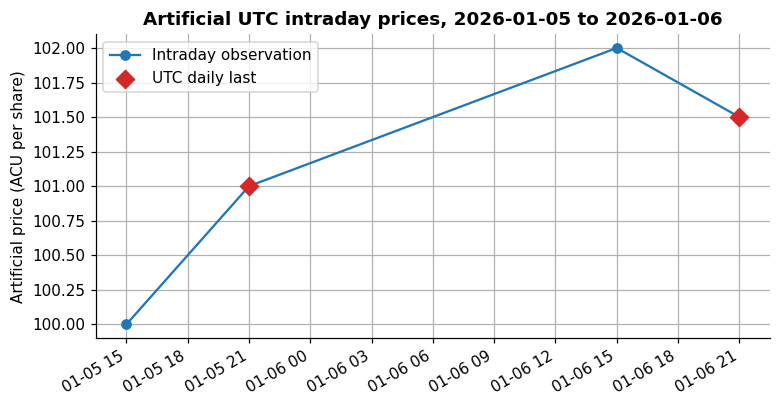

In [24]:
local_times = pd.DatetimeIndex(
    pd.to_datetime(["2026-01-05 16:00", "2026-01-06 16:00"])
).tz_localize("America/New_York")
utc_times = local_times.tz_convert("UTC")

time_conversion = pd.DataFrame(
    {
        "Local_session_label": local_times.astype(str),
        "Same_instant_in_UTC": utc_times.astype(str),
    }
)
display(
    time_conversion.style.set_caption(
        "Artificial New York timestamps and the same instants displayed in UTC"
    ).hide(axis="index")
)

nasdaq_winter_close = pd.Timestamp("2026-01-05 16:00").tz_localize(
    "America/New_York"
)
nasdaq_summer_close = pd.Timestamp("2026-06-05 16:00").tz_localize(
    "America/New_York"
)
twse_close_boundary = pd.Timestamp("2020-02-24 13:30").tz_localize(
    "Asia/Taipei"
)
real_session_boundaries = pd.DataFrame(
    {
        "Market_and_date": [
            "Nasdaq regular close, 2026-01-05",
            "Nasdaq regular close, 2026-06-05",
            "TWSE regular close, 2020-02-24",
        ],
        "Local_boundary": [
            str(nasdaq_winter_close),
            str(nasdaq_summer_close),
            str(twse_close_boundary),
        ],
        "Same_instant_UTC": [
            str(nasdaq_winter_close.tz_convert("UTC")),
            str(nasdaq_summer_close.tz_convert("UTC")),
            str(twse_close_boundary.tz_convert("UTC")),
        ],
        "What_is_established": [
            "Stated regular-session boundary",
            "Stated regular-session boundary",
            "Stated regular-session boundary",
        ],
    }
)
display(
    real_session_boundaries.style.set_caption(
        "Real exchange session boundaries converted with named time zones"
    ).hide(axis="index")
)

intraday_prices = pd.Series(
    [100.0, 101.0, 102.0, 101.5],
    index=pd.DatetimeIndex(
        pd.to_datetime(
            [
                "2026-01-05 15:00+00:00",
                "2026-01-05 21:00+00:00",
                "2026-01-06 15:00+00:00",
                "2026-01-06 21:00+00:00",
            ],
            utc=True,
        )
    ),
    name="Artificial_Intraday_Price",
)
daily_last_utc = intraday_prices.resample("D").last().dropna().rename("Daily_Last_UTC")
daily_last_observation_points = intraday_prices.groupby(intraday_prices.index.normalize()).tail(1)

display(
    intraday_prices.to_frame().style.set_caption(
        "Artificial intraday prices stored with UTC timestamps"
    )
)
display(
    daily_last_utc.to_frame().style.set_caption(
        "Last artificial observation selected within each UTC calendar day"
    )
)

ax = intraday_prices.plot(marker="o", label="Intraday observation")
ax.scatter(
    daily_last_observation_points.index,
    daily_last_observation_points.values,
    color="tab:red",
    marker="D",
    s=70,
    label="UTC daily last",
    zorder=3,
)
ax.set_ylabel("Artificial price (ACU per share)")
ax.set_title("Artificial UTC intraday prices, 2026-01-05 to 2026-01-06")
ax.legend()
plt.tight_layout()
show_figure_with_alt_text(
    ax.figure,
    "Four artificial UTC intraday prices over two days, with diamond markers identifying "
    "the last observation selected inside each UTC calendar day.",
)

assert len(daily_last_utc) == 2
assert utc_times[0].tzinfo is not None
assert nasdaq_winter_close.tz_convert("UTC").hour == 21
assert nasdaq_summer_close.tz_convert("UTC").hour == 20
assert (
    twse_close_boundary.tz_convert("UTC").strftime("%H:%M") == "05:30"
)

### Interpret the output


The New York and UTC columns show the same two instants with different clock labels. On these January dates, 16:00 in New York is displayed as 21:00 UTC.

The daily aggregation groups the separate intraday series by UTC calendar date and selects its final observation. The diamond markers identify the selected observations by shape as well as color.

Do not relabel these values as exchange closes without confirming the venue, included trading hours, time zone, and provider's daily-bar construction.

The real boundary table shows that Nasdaq's stated 16:00 Eastern close appears at 21:00 UTC in January and 20:00 UTC in June because the named time zone applies the relevant offset. The TWSE 13:30 local boundary appears at 05:30 UTC on the stated date. These conversions establish instants for session rules, not timestamps for the price rows in a particular dataset.


### Discussion questions

1. Nasdaq states a regular close of 16:00 Eastern Time. The real boundary table maps this to 21:00 UTC in January and 20:00 UTC in June. A program always selects 21:00 UTC. Identify which period can select an observation one hour after the stated local close, and specify the named-time-zone and local-session rule that should replace the fixed UTC clock time.
2. An artificial local trading session begins at 20:30 UTC and ends at 00:30 UTC on the next calendar date. A program groups rows with `resample('D')`. State how one session can be split across two UTC calendar days. Specify the session identifier or boundary information needed to calculate one Open, High, Low, Close, and Volume row for the complete session.

## Issue 19 — Do all asset returns use the same beginning and ending dates?


A portfolio return combines asset returns over one common holding interval. Matching only the ending-date labels is not enough. Each component must use the same beginning date and ending date.

If one asset has no price at an endpoint, calculating each asset return separately can create different interval lengths under the same ending-date label. This example first keeps only dates on which both artificial assets have prices. It then calculates returns from those common endpoints.

Asset E has no reported price on March 4. The code leaves it missing and does not copy the March 3 value forward. Restricting the table to common endpoints also removes Asset D's otherwise available March 4 observation from this portfolio calculation.

The real example uses closing prices for TWSE securities [2330](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330) and [2317](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2317) on February 24–27, 2020. Both official reports contain all four dates, so the paired table provides three returns with identical beginning and ending dates. The comparison is limited to the displayed closing-price fields.


### Before running the example


Identify the artificial date on which only Asset E is missing. Predict which four dates will remain as common artificial endpoints and which dates bound the return ending March 5. Then predict the number of common price dates and complete return intervals in the real TWSE pair.

,Asset_D,Asset_E
2026-03-02 00:00:00,80.000000,40.000000
2026-03-03 00:00:00,82.000000,39.000000
2026-03-04 00:00:00,81.000000,nan
2026-03-05 00:00:00,84.000000,42.000000
2026-03-06 00:00:00,83.000000,43.000000


,Asset_D,Asset_E
2026-03-02 00:00:00,80.000000,40.000000
2026-03-03 00:00:00,82.000000,39.000000
2026-03-05 00:00:00,84.000000,42.000000
2026-03-06 00:00:00,83.000000,43.000000


,Interval_start,Interval_end
2026-03-02 00:00:00,NaT,2026-03-02 00:00:00
2026-03-03 00:00:00,2026-03-02 00:00:00,2026-03-03 00:00:00
2026-03-05 00:00:00,2026-03-03 00:00:00,2026-03-05 00:00:00
2026-03-06 00:00:00,2026-03-05 00:00:00,2026-03-06 00:00:00


,Asset_D,Asset_E
2026-03-02 00:00:00,nan,nan
2026-03-03 00:00:00,0.025000,-0.025000
2026-03-05 00:00:00,0.024390,0.076923
2026-03-06 00:00:00,-0.011905,0.023810


,2330_Close_TWD,2317_Close_TWD
2020-02-24 00:00:00,320.000000,80.700000
2020-02-25 00:00:00,322.000000,82.300000
2020-02-26 00:00:00,318.500000,81.100000
2020-02-27 00:00:00,316.000000,80.300000


,Interval_start,Interval_end
2020-02-24 00:00:00,NaT,2020-02-24 00:00:00
2020-02-25 00:00:00,2020-02-24 00:00:00,2020-02-25 00:00:00
2020-02-26 00:00:00,2020-02-25 00:00:00,2020-02-26 00:00:00
2020-02-27 00:00:00,2020-02-26 00:00:00,2020-02-27 00:00:00


,2330_Close_TWD,2317_Close_TWD
2020-02-24 00:00:00,nan,nan
2020-02-25 00:00:00,0.006250,0.019827
2020-02-26 00:00:00,-0.010870,-0.014581
2020-02-27 00:00:00,-0.007849,-0.009864


,Asset_D,Asset_E
2026-03-02 00:00:00,100.000000,100.000000
2026-03-03 00:00:00,102.500000,97.500000
2026-03-04 00:00:00,101.250000,nan
2026-03-05 00:00:00,105.000000,105.000000
2026-03-06 00:00:00,103.750000,107.500000


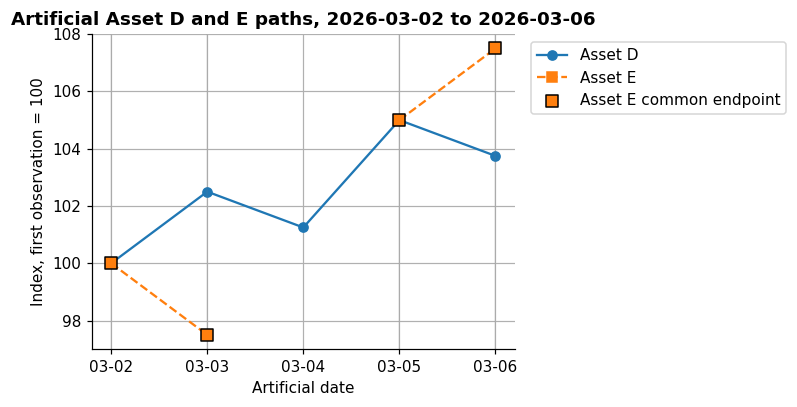

In [25]:
multi_asset_prices = pd.DataFrame(
    {
        "Asset_D": [80.0, 82.0, 81.0, 84.0, 83.0],
        "Asset_E": [40.0, 39.0, np.nan, 42.0, 43.0],
    },
    index=pd.to_datetime(
        ["2026-03-02", "2026-03-03", "2026-03-04", "2026-03-05", "2026-03-06"]
    ),
)

common_prices = multi_asset_prices.dropna(how="any")
common_returns = common_prices.pct_change(fill_method=None)

intervals = pd.DataFrame(
    {
        "Interval_start": common_prices.index.to_series().shift(1),
        "Interval_end": common_prices.index,
    },
    index=common_prices.index,
)

display(
    multi_asset_prices.style.set_caption(
        "Artificial asset prices with Asset E missing on 2026-03-04"
    )
)
display(
    common_prices.style.set_caption(
        "Price endpoints available for both artificial assets"
    )
)
display(
    intervals.style.set_caption(
        "Beginning and ending dates for returns calculated from common endpoints"
    )
)
display(
    common_returns.round(6).style.set_caption(
        "Artificial asset returns over the stated common intervals"
    )
)

twse_pair_closes = pd.DataFrame(
    {
        "2330_Close_TWD": [320.00, 322.00, 318.50, 316.00],
        "2317_Close_TWD": [80.70, 82.30, 81.10, 80.30],
    },
    index=pd.to_datetime(
        ["2020-02-24", "2020-02-25", "2020-02-26", "2020-02-27"]
    ),
)
twse_pair_returns = twse_pair_closes.pct_change(fill_method=None)
twse_pair_intervals = pd.DataFrame(
    {
        "Interval_start": twse_pair_closes.index.to_series().shift(1),
        "Interval_end": twse_pair_closes.index,
    },
    index=twse_pair_closes.index,
)
display(
    twse_pair_closes.style.set_caption(
        "Real TWSE 2330 and 2317 closing prices on common dates"
    )
)
display(
    twse_pair_intervals.style.set_caption(
        "Common beginning and ending dates for the real paired returns"
    )
)
display(
    twse_pair_returns.round(8).style.set_caption(
        "Real closing-price returns calculated over identical intervals"
    )
)

normalized_multi_asset = multi_asset_prices.div(multi_asset_prices.iloc[0]).mul(100)
display(
    normalized_multi_asset.round(2).style.set_caption(
        "Artificial price paths normalized to 100 on 2026-03-02"
    )
)
normalized_multi_asset_plot = normalized_multi_asset.rename(
    columns={"Asset_D": "Asset D", "Asset_E": "Asset E"}
)
fig, ax = plt.subplots()
ax.plot(
    normalized_multi_asset_plot.index,
    normalized_multi_asset_plot["Asset D"],
    marker="o",
    linestyle="-",
    label="Asset D",
)
ax.plot(
    normalized_multi_asset_plot.index,
    normalized_multi_asset_plot["Asset E"],
    marker="s",
    linestyle="--",
    label="Asset E",
)
for date in common_prices.index:
    ax.axvline(date, color="grey", alpha=0.12, linewidth=1)
ax.scatter(
    common_prices.index,
    normalized_multi_asset.loc[common_prices.index, "Asset_E"],
    color="tab:orange",
    edgecolor="black",
    marker="s",
    s=55,
    label="Asset E common endpoint",
    zorder=4,
)
ax.set_ylabel("Index, first observation = 100")
ax.set_xlabel("Artificial date")
ax.set_title("Artificial Asset D and E paths, 2026-03-02 to 2026-03-06")
ax.set_xticks(normalized_multi_asset.index, normalized_multi_asset.index.strftime("%m-%d"))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
show_figure_with_alt_text(
    fig,
    "Normalized artificial price paths for Assets D and E. Asset E has a visible gap on "
    "2026-03-04, and outlined square markers identify its retained common endpoints.",
)

assert len(common_prices) == 4
assert common_returns.notna().all(axis=1).sum() == 3
assert len(twse_pair_closes) == 4
assert twse_pair_returns.notna().all(axis=1).sum() == 3
assert twse_pair_returns.dropna().index.equals(twse_pair_closes.index[1:])

### Interpret the output


The common endpoint table retains March 2, 3, 5, and 6. The return ending March 5 therefore spans March 3 to March 5 for both assets.

Asset D also has a price on March 4, but that date cannot be a common endpoint because Asset E has no price. The normalized chart leaves the Asset E gap visible. Different markers and line styles distinguish the two asset paths, and the outlined square markers identify the retained Asset E endpoints.

Do not combine Asset D's March 4-to-March 5 return with Asset E's March 3-to-March 5 return under one March 5 portfolio label. Those component returns describe different holding intervals.

The real paired table has four common price dates and three common holding intervals. For example, both returns labeled 2020-02-26 begin on 2020-02-25. A matching end-date index is useful here because the beginning endpoint was also constructed and checked explicitly.


### Discussion questions

1. Using the real TWSE tables, calculate the 2330 and 2317 closing-price returns ending on 2020-02-26. State the beginning and ending date for both components. Then explain why matching only the `2020-02-26` label would be insufficient if one asset's beginning price came from 2020-02-24 instead.
2. A student forward-fills Asset E's missing March 4 price with 39, then calculates a zero return ending March 4 and a March 4-to-March 5 return. Identify the market observation that the copied value pretends to supply. Compare the intervals and values produced by forward filling with the March 3-to-March 5 common-endpoint calculation, and state which result can be supported by the original table alone.

## Issue 20 — How do beginning weights combine same-interval asset returns?


For one holding interval, multiply each asset return by that asset's weight at the beginning of the interval and add the contributions. Every asset return must use the same beginning and ending dates established in Issue 19.

The weights must contain finite numbers, match the asset labels, and sum to one under this fully invested no-leverage example. A 70% weight must be stored as `0.70`, not `70`.

The calculation shows how already chosen weights combine returns. It does not show that 70/30 is preferable to another allocation, and it does not choose or rebalance weights. Weight selection begins in Week 8.

The real-data calculation uses the paired TWSE 2330 and 2317 closing-price returns from Issue 19 and an instructor-created 70/30 beginning allocation. The official reports supply the prices, not the weights. Applying the same illustrative weights to each row demonstrates the one-interval arithmetic only; it is not a historical trading strategy or a recommendation.


### Before running the example


Use the artificial March 3-to-March 5 returns to predict the 70/30 portfolio return. Then use the real TWSE paired returns to predict the 70/30 result ending 2020-02-26. For both calculations, state why the weights must be known before the interval returns are observed.

,Starting_Weight
Asset_D,0.700000
Asset_E,0.300000


,Asset_D,Asset_E,Portfolio_Return
2026-03-02 00:00:00,nan,nan,nan
2026-03-03 00:00:00,0.025000,-0.025000,0.010000
2026-03-05 00:00:00,0.024390,0.076923,0.040150
2026-03-06 00:00:00,-0.011905,0.023810,-0.001190


,Asset_D_Contribution,Asset_E_Contribution,Portfolio_Return
2026-03-02 00:00:00,nan,nan,nan
2026-03-03 00:00:00,0.017500,-0.007500,0.010000
2026-03-05 00:00:00,0.017073,0.023077,0.040150
2026-03-06 00:00:00,-0.008333,0.007143,-0.001190


,Illustrative_Beginning_Weight
2330_Close_TWD,0.700000
2317_Close_TWD,0.300000


,2330_Close_TWD,2317_Close_TWD,2330_Close_TWD_Contribution,2317_Close_TWD_Contribution,Illustrative_Portfolio_Return
2020-02-24 00:00:00,nan,nan,nan,nan,nan
2020-02-25 00:00:00,0.006250,0.019827,0.004375,0.005948,0.010323
2020-02-26 00:00:00,-0.010870,-0.014581,-0.007609,-0.004374,-0.011983
2020-02-27 00:00:00,-0.007849,-0.009864,-0.005495,-0.002959,-0.008454


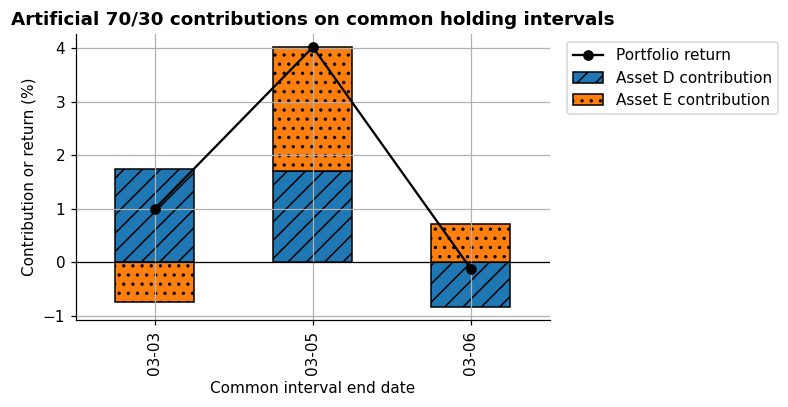

Hand portfolio return ending March 5: 0.0401500938086304


In [26]:
weights = pd.Series({"Asset_D": 0.70, "Asset_E": 0.30}, name="Starting_Weight")

if not np.isfinite(weights).all():
    raise ValueError("Weights must be finite.")
if not np.isclose(weights.sum(), 1.0):
    raise ValueError("Weights must sum to one for this exercise.")
if set(weights.index) != set(common_returns.columns):
    raise ValueError("Weight labels must match the return columns.")

weights = weights.reindex(common_returns.columns)

portfolio_return = common_returns.mul(weights, axis=1).sum(
    axis=1,
    min_count=len(weights),
).rename("Portfolio_Return")

portfolio_table = common_returns.assign(Portfolio_Return=portfolio_return)
display(
    weights.to_frame().style.set_caption(
        "Beginning weights for the artificial one-period portfolio calculation"
    )
)
display(
    portfolio_table.round(6).style.set_caption(
        "Same-interval asset returns and their fixed-weight portfolio return"
    )
)

return_contributions = common_returns.mul(weights, axis=1)
return_contributions.columns = [f"{column}_Contribution" for column in return_contributions.columns]
contribution_table = pd.concat([return_contributions, portfolio_return], axis=1)
display(
    contribution_table.round(6).style.set_caption(
        "Weighted asset contributions that add to the portfolio return"
    )
)

twse_example_weights = pd.Series(
    {"2330_Close_TWD": 0.70, "2317_Close_TWD": 0.30},
    name="Illustrative_Beginning_Weight",
)
twse_example_weights = twse_example_weights.reindex(twse_pair_returns.columns)
if not np.isfinite(twse_example_weights).all():
    raise ValueError("Real-example weights must be finite.")
if not np.isclose(twse_example_weights.sum(), 1.0):
    raise ValueError("Real-example weights must sum to one.")

twse_return_contributions = twse_pair_returns.mul(
    twse_example_weights, axis=1
)
twse_return_contributions.columns = [
    f"{column}_Contribution" for column in twse_return_contributions.columns
]
twse_example_portfolio_return = twse_return_contributions.sum(
    axis=1,
    min_count=len(twse_example_weights),
).rename("Illustrative_Portfolio_Return")
twse_portfolio_table = pd.concat(
    [twse_pair_returns, twse_return_contributions, twse_example_portfolio_return],
    axis=1,
)
display(
    twse_example_weights.to_frame().style.set_caption(
        "Instructor-created beginning weights for the real-data arithmetic example"
    )
)
display(
    twse_portfolio_table.round(8).style.set_caption(
        "Real TWSE same-interval returns, weighted contributions, and portfolio return"
    )
)

plot_contributions = 100 * return_contributions.dropna(how="any")
plot_portfolio_return = 100 * portfolio_return.loc[plot_contributions.index]
plot_contributions.index = plot_contributions.index.strftime("%m-%d")
plot_contributions.columns = ["Asset D contribution", "Asset E contribution"]
ax = plot_contributions.plot(
    kind="bar",
    stacked=True,
    color=["tab:blue", "tab:orange"],
    edgecolor="black",
)
for patch_number, bar in enumerate(ax.patches):
    bar.set_hatch("//" if patch_number < len(plot_contributions) else "..")
ax.plot(
    np.arange(len(plot_contributions)),
    plot_portfolio_return.values,
    color="black",
    marker="o",
    linewidth=1.5,
    label="Portfolio return",
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Contribution or return (%)")
ax.set_xlabel("Common interval end date")
ax.set_title("Artificial 70/30 contributions on common holding intervals")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
show_figure_with_alt_text(
    ax.figure,
    "Stacked bars show the artificial Asset D and Asset E weighted return contributions "
    "for three common intervals; a black line marks their summed portfolio return.",
)

march_5_hand = (
    0.70 * (84.0 / 82.0 - 1.0)
    + 0.30 * (42.0 / 39.0 - 1.0)
)
print("Hand portfolio return ending March 5:", march_5_hand)

assert pd.isna(portfolio_return.iloc[0])
assert np.isclose(portfolio_return.loc["2026-03-05"], march_5_hand)
assert pd.isna(twse_example_portfolio_return.iloc[0])
assert np.allclose(
    twse_return_contributions.dropna().sum(axis=1),
    twse_example_portfolio_return.dropna(),
)

### Interpret the output


The first portfolio return remains missing because the first common price row has no earlier common endpoint. The March 5 calculation uses the March 3-to-March 5 return for both assets and the stated 70/30 weights known at the beginning of that interval.

The contribution table shows each weight multiplied by its matching asset return. The two contributions add to the black portfolio-return line. The stacked bars use labels, positions, and hatch patterns as well as color.

The calculation does not include a cash asset, leverage, short positions, trading costs, or weight changes within the interval. It also does not evaluate whether the 70/30 allocation should be used again.

Each nonmissing row is a separate one-period calculation that assumes 70/30 beginning weights for that row's interval. Do not compound these rows as one continuous strategy unless trades, weight drift, and any return to 70/30 are modeled explicitly.

The real-data table uses the same beginning and ending dates for both component returns. Each portfolio row equals the 2330 contribution plus the 2317 contribution. Because 70/30 is imposed separately at the beginning of every displayed interval, the rows must not be described as one continuous buy-and-hold portfolio without modeling how weights drift and when trades restore them.


### Discussion questions

1. Use the real TWSE 2330 and 2317 returns ending on 2020-02-26 and the illustrative 70/30 beginning weights to reproduce both weighted contributions and the portfolio return by hand. State the latest time at which the weights may be determined. Explain why weights calculated from the 2020-02-26 closing prices would use end-of-interval information.
2. Starting from the illustrative 70/30 allocation on 2020-02-25, calculate the ending value invested in 2330 and 2317 after their returns ending 2020-02-26, assuming one initial portfolio unit and no trades. Divide each ending asset value by total ending wealth to obtain the ending weights. Explain why imposing 70/30 again for the next row would require a separate rebalancing decision and transaction record.

# Independent practice issues

The four exercises below use new values and variable names. Preserve your prediction before coding, the complete input, calculations, checks, revisions, and unresolved questions. Starter cells intentionally do not contain solutions.

## Practice issue 1 — Select fields across corporate actions

Case A changes from price 120 with one share to price 40 with three shares after an artificial three-for-one split. Case B changes from price 75 to 73 and pays an artificial cash distribution of 4.

Calculate raw price return and position-value return for Case A. Calculate price return and simplified holding-period return for Case B. Then list the real provider fields required and one possible double-counting error.

### Discussion questions

1. For Case A, compare the raw price return with the position-value return. A provider later states that its selected price field already adjusts the historical series for the three-for-one split. Specify which manual correction must be removed, which provider fields must be saved, and how applying both corrections would change the return calculation.
2. For Case B, suppose the investor bought after the ex-dividend date but before the payment date. Identify the event dates and ownership record needed before adding the cash distribution to this investor's return. Calculate and label the result both with and without the cash amount; do not assume eligibility from the payment date alone.

In [27]:
practice_1_inputs = pd.DataFrame(
    {
        "Case": ["A_before", "A_after", "B_before", "B_after"],
        "Price": [120.0, 40.0, 75.0, 73.0],
        "Shares": [1.0, 3.0, 1.0, 1.0],
        "Cash_distribution": [0.0, 0.0, 0.0, 4.0],
    }
).set_index("Case")

display(
    practice_1_inputs.style.set_caption(
        "Practice 1 artificial split and cash-distribution inputs"
    )
)
print("Create new variables for the four required returns and add explicit assertions.")

,Price,Shares,Cash_distribution
Case,,,
A_before,120.000000,1.000000,0.000000
A_after,40.000000,3.000000,0.000000
B_before,75.000000,1.000000,0.000000
B_after,73.000000,1.000000,4.000000


Create new variables for the four required returns and add explicit assertions.


## Practice issue 2 — Reconcile returns and terminal wealth

Use the five artificial prices below. Calculate simple and log returns, reconcile their identity, construct a wealth index, verify the endpoint price ratio, and compare arithmetic with geometric mean return.

### Discussion questions

1. Build an interval table that lists every beginning date, ending date, beginning price, ending price, simple return, log return, and converted simple return. Identify the one row that has no return and explain why changing it to zero would create an interval not present in the input.
2. A second student adds the four simple returns and reports the sum as the February 2-to-February 6 return. Compare that number with the compounded return and endpoint price ratio. Identify which equality the student's result fails and state why passing every corrected identity still cannot support a claim about predictability or future performance.

In [28]:
practice_2_price = pd.Series(
    [100.0, 104.0, 101.0, 106.0, 103.0],
    index=pd.to_datetime(
        ["2026-02-02", "2026-02-03", "2026-02-04", "2026-02-05", "2026-02-06"]
    ),
    name="Practice_2_Price",
)

display(
    practice_2_price.to_frame().style.set_caption(
        "Practice 2 artificial price path, 2026-02-02 to 2026-02-06"
    )
)
print("Predict terminal wealth and the ordering of the two means before calculating.")

,Practice_2_Price
2026-02-02 00:00:00,100.000000
2026-02-03 00:00:00,104.000000
2026-02-04 00:00:00,101.000000
2026-02-05 00:00:00,106.000000
2026-02-06 00:00:00,103.000000


Predict terminal wealth and the ordering of the two means before calculating.


## Practice issue 3 — Audit a damaged financial table

Audit the table below without repairing it. Check parsing, order, duplicates, missing prices, nonpositive prices, and absent time-zone metadata. For each failed check, state why it matters, evidence needed before repair, proposed action or pending decision, and effect on the retained sample.

### Discussion questions

1. Without changing the table, identify every pair of rows that cannot yet define a return. For each pair, state whether the obstruction is repeated timestamps, reverse order, a missing price, a zero price, or an unstated time zone. List the exact source information required before that pair can be used.
2. Compare two proposed repairs: keep the first March 3 row and delete every other flagged row, or keep all original rows and add verified status and version fields before selecting observations. State how many original observations each proposal discards, which unresolved facts the first proposal hides, and which columns the second proposal must add before return calculation.

In [29]:
practice_3_records = pd.DataFrame(
    [
        ["2026-03-02 16:00", 50.0, 2_000],
        ["2026-03-03 16:00", 51.0, 2_100],
        ["2026-03-03 16:00", 51.2, 2_100],
        ["2026-03-05 16:00", np.nan, 1_900],
        ["2026-03-04 16:00", 0.0, 2_200],
    ],
    columns=["Timestamp", "Analysis_Price", "Volume"],
)

display(
    practice_3_records.style.set_caption(
        "Practice 3 damaged artificial records in original row order"
    ).hide(axis="index")
)
print("Preserve this original table and create a separate Boolean audit table.")

Timestamp,Analysis_Price,Volume
2026-03-02 16:00,50.000000,2000
2026-03-03 16:00,51.000000,2100
2026-03-03 16:00,51.200000,2100
2026-03-05 16:00,nan,1900
2026-03-04 16:00,0.000000,2200


Preserve this original table and create a separate Boolean audit table.


## Case 4 — Integrated financial-data and return case

This case brings together the Week 2 documentation, audit, return, time-alignment, and portfolio calculations. The inputs remain artificial. They do not describe real securities, a real venue, or a provider's actual field construction.

The source record states that the table contains artificial closing prices for two artificial common stocks in the same artificial currency. The dates are artificial session labels rather than timezone-aware timestamps. No split or cash distribution occurs in the displayed interval. Asset G has no observed price on May 4. Do not forward-fill that value.

### Part A — Document the inputs

1. Complete the data-processing record using only the facts supplied by the case.
2. For the source, write `instructor-provided artificial table; not downloaded` rather than inventing a provider or retrieval date.
3. Record the unresolved timezone as `pending`; do not infer a real exchange convention.
4. State why `Close` is the selected analysis field for this artificial question and why that decision cannot be transferred automatically to a real provider.

### Part B — Audit before calculating

5. Verify date parsing, ascending order, uniqueness, positive observed prices, matching asset labels, finite weights, and a fully invested 60/40 allocation.
6. Produce a missing-value table and preserve the original Asset G gap.
7. State what additional calendar evidence would be required before classifying a similar real-data gap.
8. Confirm that no manual split or dividend adjustment is applied under the stated artificial assumptions.

### Part C — Calculate and reconcile

9. Construct the common endpoint price table before calculating either asset return.
10. Label the start and end of every resulting common holding interval.
11. Calculate simple and log returns for both assets and reconcile them numerically.
12. Validate the weight labels, finiteness, nonnegativity, and sum before multiplying returns.
13. Calculate each asset's weighted contribution and the one-period portfolio return.
14. Independently verify the portfolio return ending May 7 by substituting prices and weights by hand.
15. Construct a portfolio wealth index beginning at one on the first common endpoint.

### Part D — Communicate the evidence

16. Produce an audit table, common-endpoint table, interval-and-return table, contribution table, and wealth table.
17. Produce one figure that keeps the missing observation visible and identifies the retained common endpoints.
18. Write one conclusion supported by the artificial calculation and one conclusion the case cannot support.

### Discussion questions

1. Asset G has no May 4 price. Calculate the holding intervals produced by the required common-endpoint method. Then describe the additional zero return and shorter next interval that would appear if May 1 were copied into May 4. State which market observation the copied value falsely claims to provide and which interval set is supported by the original input.
2. Suppose every date, return, weight, contribution, and wealth assertion passes. List the exact additional records required before the output could describe a real investable portfolio: provider and asset identifiers, price-field construction, venue calendar, timestamp meaning, corporate actions, weight decision time, execution price, trading costs, and currency treatment. For each missing record, identify the calculation or investment claim that must remain unavailable.

### Required evidence

Preserve the four input tables below, every audit result, explicit interval labels, return identities, hand calculation, portfolio contributions, wealth index, figure, assertions, unresolved entries, and conclusion boundary. A successful run demonstrates a reproducible artificial calculation; it does not establish predictability, profitability after costs, or future performance.

In [30]:
practice_4_source_record = pd.DataFrame(
    {
        "Recorded_value": [
            "instructor-created artificial case",
            "Week 2 Case 4",
            "embedded fixed table",
            "instructor-created course example; the public repository contains no approved common market dataset",
            "artificial session labels",
            "one observation per artificial session",
            "no split or cash distribution in the displayed interval",
            "no real-market claim permitted",
        ]
    },
    index=[
        "Provider",
        "Dataset",
        "Location",
        "Redistribution",
        "Timestamp meaning",
        "Observation frequency",
        "Corporate actions and distributions",
        "Claim boundary",
    ],
)

practice_4_asset_master = pd.DataFrame(
    {
        "Asset": ["Asset_F", "Asset_G"],
        "Security_type": ["Artificial common stock", "Artificial common stock"],
        "Venue": ["Artificial venue", "Artificial venue"],
        "Currency": ["ACU", "ACU"],
        "Selected_field": ["Artificial closing price", "Artificial closing price"],
        "Unit": ["ACU per share", "ACU per share"],
    }
).set_index("Asset")

practice_4_prices = pd.DataFrame(
    {
        "Asset_F": [90.0, 92.0, 91.0, 95.0, 94.0],
        "Asset_G": [45.0, np.nan, 46.0, 48.0, 47.0],
    },
    index=pd.to_datetime(
        ["2026-05-01", "2026-05-04", "2026-05-05", "2026-05-07", "2026-05-08"]
    ),
)
practice_4_weights = pd.Series(
    {"Asset_F": 0.60, "Asset_G": 0.40},
    name="Starting_Weight",
)

practice_4_case_inventory = pd.DataFrame(
    {
        "Object": ["Source record", "Asset master", "Price table", "Starting weights"],
        "Rows": [
            len(practice_4_source_record),
            len(practice_4_asset_master),
            len(practice_4_prices),
            len(practice_4_weights),
        ],
        "First student action": [
            "Complete pending documentation",
            "Verify identity, field, currency, and unit",
            "Audit dates, missing values, and positive observed prices",
            "Verify labels, constraints, and decision timing",
        ],
    }
)

display(
    practice_4_source_record.style.set_caption(
        "Practice 4 artificial source record"
    )
)
display(
    practice_4_asset_master.style.set_caption(
        "Practice 4 artificial asset definitions"
    )
)
display(
    practice_4_prices.style.set_caption(
        "Practice 4 artificial prices with the Asset G gap preserved"
    )
)
display(
    practice_4_weights.to_frame("Starting_Weight").style.set_caption(
        "Practice 4 assumed beginning portfolio weights"
    )
)
display(
    practice_4_case_inventory.style.set_caption(
        "Practice 4 input inventory and first required student action"
    ).hide(axis="index")
)
print("Case inputs loaded. Preserve them before creating audit or calculation objects.")
print("First calculation rule: build common price endpoints before calculating asset returns.")

,Recorded_value
Provider,instructor-created artificial case
Dataset,Week 2 Case 4
Location,embedded fixed table
Redistribution,instructor-created course example; the public repository contains no approved common market dataset
Timestamp meaning,artificial session labels
Observation frequency,one observation per artificial session
Corporate actions and distributions,no split or cash distribution in the displayed interval
Claim boundary,no real-market claim permitted


,Security_type,Venue,Currency,Selected_field,Unit
Asset,,,,,
Asset_F,Artificial common stock,Artificial venue,ACU,Artificial closing price,ACU per share
Asset_G,Artificial common stock,Artificial venue,ACU,Artificial closing price,ACU per share


,Asset_F,Asset_G
2026-05-01 00:00:00,90.000000,45.000000
2026-05-04 00:00:00,92.000000,nan
2026-05-05 00:00:00,91.000000,46.000000
2026-05-07 00:00:00,95.000000,48.000000
2026-05-08 00:00:00,94.000000,47.000000


,Starting_Weight
Asset_F,0.600000
Asset_G,0.400000


Object,Rows,First student action
Source record,8,Complete pending documentation
Asset master,2,"Verify identity, field, currency, and unit"
Price table,5,"Audit dates, missing values, and positive observed prices"
Starting weights,2,"Verify labels, constraints, and decision timing"


Case inputs loaded. Preserve them before creating audit or calculation objects.
First calculation rule: build common price endpoints before calculating asset returns.


# Terminology reference

Use these meanings when interpreting the Week 2 examples. For real data, provider definitions and the stated return convention remain authoritative.

| Term | Meaning used in Week 2 |
|---|---|
| price level | A price observation with an asset, time, field, currency, and unit |
| price return | Relative price change over a stated holding interval |
| holding-period return | Return over one stated interval, including the distributions explicitly included by its convention |
| simple return | $P_t/P_{t-1}-1$ for a consistently defined price series |
| log return | $\ln(P_t/P_{t-1})$ for positive prices |
| cumulative return | Compounded change across consecutive holding intervals |
| wealth index | Growth of one initial unit under the stated return sequence |
| arithmetic mean return | Sum of observed returns divided by their count |
| geometric mean return | Constant per-period return that reproduces the compounded terminal wealth |
| adjusted price | Provider-defined price series adjusted for specified events |
| total-return series | Provider-defined series that includes specified distributions under a stated convention |
| trading calendar | The sessions and special schedules defined for a particular market |
| observation frequency | Interval or sampling rule represented by consecutive observations |
| common holding interval | Shared start and end boundaries for returns being combined |
| portfolio return | Weighted sum of same-interval asset returns under stated weights |

# Troubleshooting reference

Use the first check before changing code or data. Preserve the failed output and document any later correction.

| Symptom | First check | Safe next action |
|---|---|---|
| `ModuleNotFoundError` | Read the missing package name | Install only the required package in the current environment, restart if needed, and rerun from the first cell |
| `ValueError` while creating a `DataFrame` | Compare values per record with the column count | Correct the source record before calculating |
| Date index remains `object` | Display `dtypes` and the parsing cell | Use `pd.to_datetime` with the expected format and `errors="raise"` |
| Duplicate timestamp | Display all rows sharing that timestamp and their identifiers | Preserve them and investigate the source key before selecting or removing a row |
| First return is `NaN` | Check whether an earlier price exists | Keep it missing in the return series |
| Zero return appears beside a missing price | Inspect fills before `pct_change` | Remove automatic filling and document the missing-value decision |
| Log return is infinite or missing unexpectedly | Display the two prices in the ratio | Stop on zero, negative, missing, or misaligned prices |
| Simple and log returns do not reconcile | Check order, alignment, and units | Recalculate both from the same two price observations |
| Wealth endpoint identity fails | Compare first price, last price, and included returns | Repair interval or compounding logic before interpreting the result |
| Weekly return differs from compounded daily return | List both weekly endpoints and included daily intervals | Align endpoints and use last observed analysis prices before calculating returns |
| Weekly OHLCV looks implausible | Inspect the aggregation used for each field | Use first, maximum, minimum, last, or sum only when it matches the field definition |
| A portfolio return appears on the first price date | Inspect component returns and `min_count` | Require every component return; do not treat missing as zero |
| Assets have different return horizons | Display start and end prices for each component | Align common price endpoints first and then recalculate returns |
| Return is 100 times too large | Inspect decimal-to-percent conversion | Convert to percent once, only for reporting |
| Assertion fails | Read the variables and rows used by that assertion | Preserve the failure and diagnose the data or formula; do not delete the assertion |

# Optional extensions and sources

## Optional extensions

These activities are not required for Week 2 completion:

- Add a third artificial asset in another currency and list the additional foreign-exchange information needed before forming one investor-currency portfolio return.
- Compare weekly OHLCV aggregation with an intentionally incorrect column-wise mean and explain every affected field.
- Introduce an extreme artificial return and prepare two competing explanations: a real event and a data or corporate-action error. State the evidence needed to distinguish them.
- Compare a price-only wealth index with a separately specified dividend-inclusive artificial return series without treating either as a provider's adjusted field.
- Create a normalized-price chart that starts each artificial asset at 1 and label the period, frequency, units, and artificial-data status.

## Official software references

- [`pandas.to_datetime`](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) parses date-like values.
- [`pandas.Series.pct_change`](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html) calculates fractional change; its result is not automatically a percentage.
- [`pandas.DataFrame.resample`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) groups time-series observations by a stated frequency before an aggregation is applied.
- [pandas time-series documentation](https://pandas.pydata.org/docs/user_guide/timeseries.html) documents time indexes, frequency conversion, and time-zone operations.
- [`numpy.log`](https://numpy.org/doc/stable/reference/generated/numpy.log.html), [`numpy.log1p`](https://numpy.org/doc/stable/reference/generated/numpy.log1p.html), and [`numpy.expm1`](https://numpy.org/doc/stable/reference/generated/numpy.expm1.html) support the log-return reconciliation used in the lesson.

## Financial and market references

- Campbell, J. Y., Lo, A. W., & MacKinlay, A. C. (1997). *The Econometrics of Financial Markets*. Princeton University Press, Chapter 1, “Prices, Returns, and Compounding,” pp. 9–13. [Publisher chapter record](https://doi.org/10.1515/9781400830213-005).
- The Taiwan Stock Exchange [daily trading report for security 2330](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2330) provides the February 2020 fields and observations used in the real source-reading, OHLCV, return, compounding, date, quality, calendar, and paired-asset examples.
- The corresponding TWSE [daily trading report for security 2317](https://www.twse.com.tw/exchangeReport/STOCK_DAY?date=20200224&response=html&stockNo=2317) provides the second closing-price series used in Issues 19–20.
- The official [TWSE market-information specification](https://www.twse.com.tw/staticFiles/product/broker/TWSE%E9%9B%86%E4%B8%AD%E5%B8%82%E5%A0%B4%E5%8D%B3%E6%99%82%E4%BA%A4%E6%98%93%E8%B3%87%E8%A8%8A%E5%82%B3%E8%BC%B8%E8%A6%8F%E6%A0%BC%E6%9B%B8%28B.11.17%29%28201903%29-English.pdf) documents the trading-currency code used to interpret the price unit in that example.
- TWSE [Information Services](https://www.twse.com.tw/en/products/information/information.html) states the Monday-through-Friday scope of exchange trading hours, subject to public holidays or other provisions, used in the Issue 17 calendar example.
- The TWSE [Trading Mechanism Introduction](https://www.twse.com.tw/en/products/system/trading.html) states regular trading hours of 9:00 to 13:30 local time, used only as a session boundary in Issue 18.
- Meta Platforms' [Form 8-K filed with the SEC](https://www.sec.gov/Archives/edgar/data/1326801/000132680122000070/fb-20220531.htm) identifies the security class, listing venue, former ticker, new ticker, and effective trading date used in the Issue 3 example.
- The [company announcement attached to that SEC filing](https://www.sec.gov/Archives/edgar/data/1326801/000132680122000070/may312022-exhibit991.htm) states that `META` replaced `FB` and that the CUSIP number remained unchanged.
- Apple's [July 30, 2020 announcement](https://www.apple.com/newsroom/2020/07/apple-reports-third-quarter-results/) and [investor-relations history](https://investor.apple.com/dividend-history/default.aspx) provide the four-for-one split ratio and dates used in Issue 6.
- Microsoft's [June 12, 2024 dividend announcement](https://news.microsoft.com/source/2024/06/12/microsoft-announces-quarterly-dividend-23/) and [dividend history](https://www.microsoft.com/en-us/Investor/dividends-and-stock-history) provide the amount and dates used in Issue 7.
- The Federal Reserve's [July 26, 2023 FOMC statement](https://www.federalreserve.gov/newsevents/pressreleases/monetary20230726a.htm) and [record of policy actions](https://www.federalreserve.gov/publications/2023-ar-record-of-policy-actions-of-the-board-of-governors.htm) provide the target range and 25-basis-point description used in Issue 8.
- The U.S. Securities and Exchange Commission's Investor.gov pages on [stock splits](https://www.investor.gov/introduction-investing/investing-basics/glossary/stock-split), [dividends](https://www.investor.gov/introduction-investing/investing-basics/glossary/dividend), and [investment returns](https://www.investor.gov/introduction-investing) support the basic split, distribution, and compound-growth distinctions used in the artificial examples.
- Nasdaq's [trading schedule](https://www.nasdaq.com/market-activity/stock-market-holiday-schedule) provides the stated 9:30 a.m. to 4:00 p.m. Eastern Time regular-session boundary used in Issue 18 and illustrates why market calendars need holidays and special closes.

The textbook supports standard return and compounding notation. The official company, exchange, central-bank, and regulator pages support only the event terms, market fields, boundaries, and distinctions identified above. The manually copied rows and event terms are teaching subsets rather than live feeds. None of these references defines the construction, correction history, or redistribution rights of a future common course dataset; those items remain pending until the instructor approves one.

# Completion evidence

## Required submission

Submit this completed notebook or an exported report containing:

1. the eight-item data-processing record in the preparation section of this notebook, completed once for Case 4;
2. every worked-example cell with its visible audit output;
3. at least one written response selected from the discussion questions for each of Issues 1–20, plus any additional responses designated during class;
4. predictions, calculations, revisions, and preserved evidence for Practice issues 1–3 and Case 4;
5. one conclusion supported by the artificial evidence and one conclusion it cannot support.

## Completion conditions

The Week 2 work is complete when another student can:

- identify the data source, asset context, observation timing, selected field, and reporting unit;
- distinguish provider evidence from an access library and query specification;
- rerun every worked example without an execution error;
- reproduce return identities and hand calculations;
- explain every missing first return and every retained unresolved data problem;
- align multi-asset returns over common holding intervals;
- distinguish a fixed-weight arithmetic example from a method for selecting weights; and
- state why the notebook does not establish predictability, profitability, or future performance.

For the Issue 2 yfinance example, submit the query record and retrieval summary, not downloaded raw rows. The source record, field definitions, return calculations, date checks, and alignment evidence begin the data documentation required by the [Report 1 criteria](../10/week10_main.md). Week 2 does not change the report weights or add another grading criterion.

## Exit evidence

Complete these statements:

```text
The price or return field I used represents ______.
The most consequential data problem I checked was ______ because ______.
My multi-asset returns share the interval from ______ to ______.
The Week 2 evidence supports the conclusion that ______.
The Week 2 evidence does not support the conclusion that ______.
Before using real data, I still need provider evidence for ______.
```

A correct historical return describes the selected data, interval, and assumptions. It does not establish predictability, profitability after costs, or future investment performance.